##**1.Project Objective & Dataset Description**

**Problem Statement**

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing 1,502 out of 2,224 passengers and crew. This tragedy shocked the world and led to better safety regulations for ships.

This notebook performs a comprehensive, end-to-end data science investigation to answer the core question:

"What factors determined whether a passenger survived the Titanic disaster?"

**Dataset Description**

### Source:
The dataset is the classic **Kaggle Titanic Dataset** — one of the most well-known datasets in data science education.

### Feature Dictionary

| Feature | Type | Description |
|---------|------|-------------|
| `PassengerId` | Integer | Serial Number |
| `Survived` | Binary (0/1) | **Target variable** — 0 = Did not survive, 1 = Survived |
| `Pclass` | Ordinal (1/2/3) | Ticket class: 1st = Upper, 2nd = Middle, 3rd = Lower |
| `Name` | String | Full name of the passenger |
| `Sex` | Categorical | Gender: male / female |
| `Age` | Continuous | Age in years (fractional for < 1 year) |
| `SibSp` | Integer | No. of siblings / spouses aboard |
| `Parch` | Integer | No. of parents / children aboard |
| `Ticket` | String | Ticket number |
| `Fare` | Continuous | Passenger fare in British Pounds |
| `Cabin` | String | Cabin number (highly missing) |
| `Embarked` | Categorical | Port of Embarkation: C=Cherbourg, Q=Queenstown, S=Southampton |

### Target Variable
- **0** → Did Not Survive
- **1** → Survived

---

Importing Libraries

In [1]:
import pandas as pd # for data manipulation
import numpy as np # for numeric calculations on data

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#statiscal tests
from scipy.stats import (
    chi2_contingency,   # Chi-Square test of independence
    ttest_ind,          # Independent samples t-test
    mannwhitneyu,       # Non-parametric alternative to t-test
    shapiro,            # Shapiro-Wilk normality test
    pointbiserialr,     # Point-biserial correlation
    levene,             # Levene's test for equal variances
    normaltest          # D'Agostino-Pearson normality test
)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)


import warnings
warnings.filterwarnings('ignore')

##**2.Dataset Overview**

The dataset contains passenger details such as:
- Demographics (Age, Sex)
- Socio-economic status (Pclass, Fare)
- Family information (SibSp, Parch)
- Travel details (Embarked, Cabin)



In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape #returns number of rows and columns

(891, 12)

In [5]:
df.info() #gives all the columns and their data-type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe().T.style.background_gradient(cmap='Greys', axis=1) #gives the basic statistics of each column

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000000,446.000000,257.353842,1.000000,223.500000,446.000000,668.500000,891.000000
Survived,891.000000,0.383838,0.486592,0.000000,0.000000,0.000000,1.000000,1.000000
Pclass,891.000000,2.308642,0.836071,1.000000,2.000000,3.000000,3.000000,3.000000
Age,714.000000,29.699118,14.526497,0.420000,20.125000,28.000000,38.000000,80.000000
SibSp,891.000000,0.523008,1.102743,0.000000,0.000000,0.000000,1.000000,8.000000
Parch,891.000000,0.381594,0.806057,0.000000,0.000000,0.000000,0.000000,6.000000
Fare,891.000000,32.204208,49.693429,0.000000,7.910400,14.454200,31.000000,512.329200


In [7]:
# Categorical summary statistics
df.describe(include='object').T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


## **3.Checking Missing Values & Outliers**

Real-world datasets often contain missing data.  
We identify which columns have missing values.

In [8]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


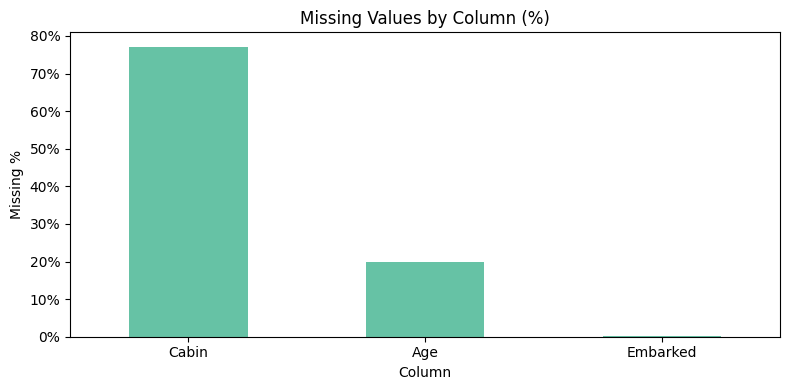

In [9]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing['Missing %'].plot(kind='bar', color=sns.color_palette('Set2')[0], ax=ax)
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

OUTLIER DETECTION (IQR METHOD)
  Age      | Q1=20.1 Q3=38.0 IQR=17.9 | Bounds=[-6.7, 64.8] | Outliers=11
  Fare     | Q1=7.9 Q3=31.0 IQR=23.1 | Bounds=[-26.7, 65.6] | Outliers=116


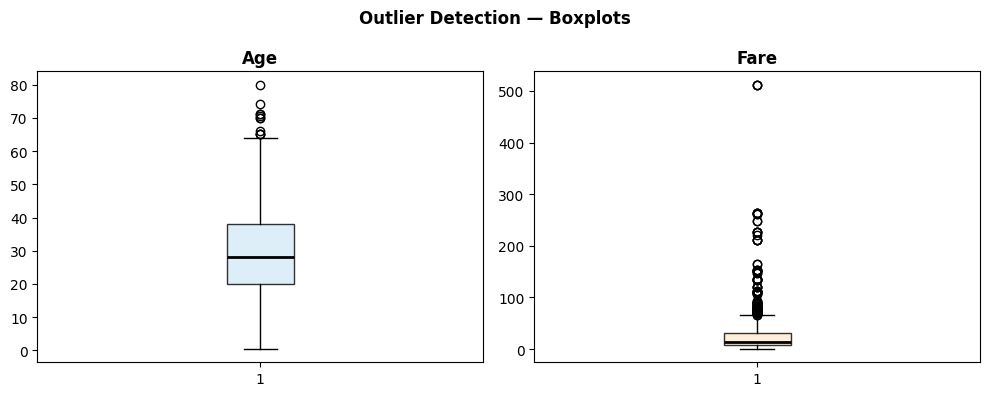

In [10]:
# Outlier Detection — IQR Method
print("OUTLIER DETECTION (IQR METHOD)")
print("="*60)

for col in ['Age', 'Fare']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f"  {col:<8} | Q1={Q1:.1f} Q3={Q3:.1f} IQR={IQR:.1f} "
          f"| Bounds=[{lower:.1f}, {upper:.1f}] | Outliers={n_out}")

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, color in zip(
    axes,
    ['Age', 'Fare'],
    ['#d6eaf8', '#fdebd0']
):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.8),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontweight='bold')

fig.suptitle("Outlier Detection — Boxplots", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## **4. Data Cleaning**

To prepare the dataset for analysis, we handle missing values and remove unnecessary columns.

Steps taken:
- Fill missing **Age** values using the title based method
- Fill missing **Embarked** values using the most common port
- Remove the **Cabin** and replace it with **has_cabin** column because **Cabin** contains too many missing values

IMPROVED AGE IMPUTATION - TITLE-BASED METHOD

BEFORE IMPUTATION:
Missing Age values: 177
Percentage: 19.87%

Original titles found:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

🔧 FILLING MISSING VALUES:
Mr           | Filled 119 missing values with median: 30.0
Mrs          | Filled  17 missing values with median: 35.0
Miss         | Filled  36 missing values with median: 21.0
Master       | Filled   4 missing values with median: 3.5
Rare         | Filled   1 missing values with median: 48.5

VISUALIZING BEFORE AND AFTER:


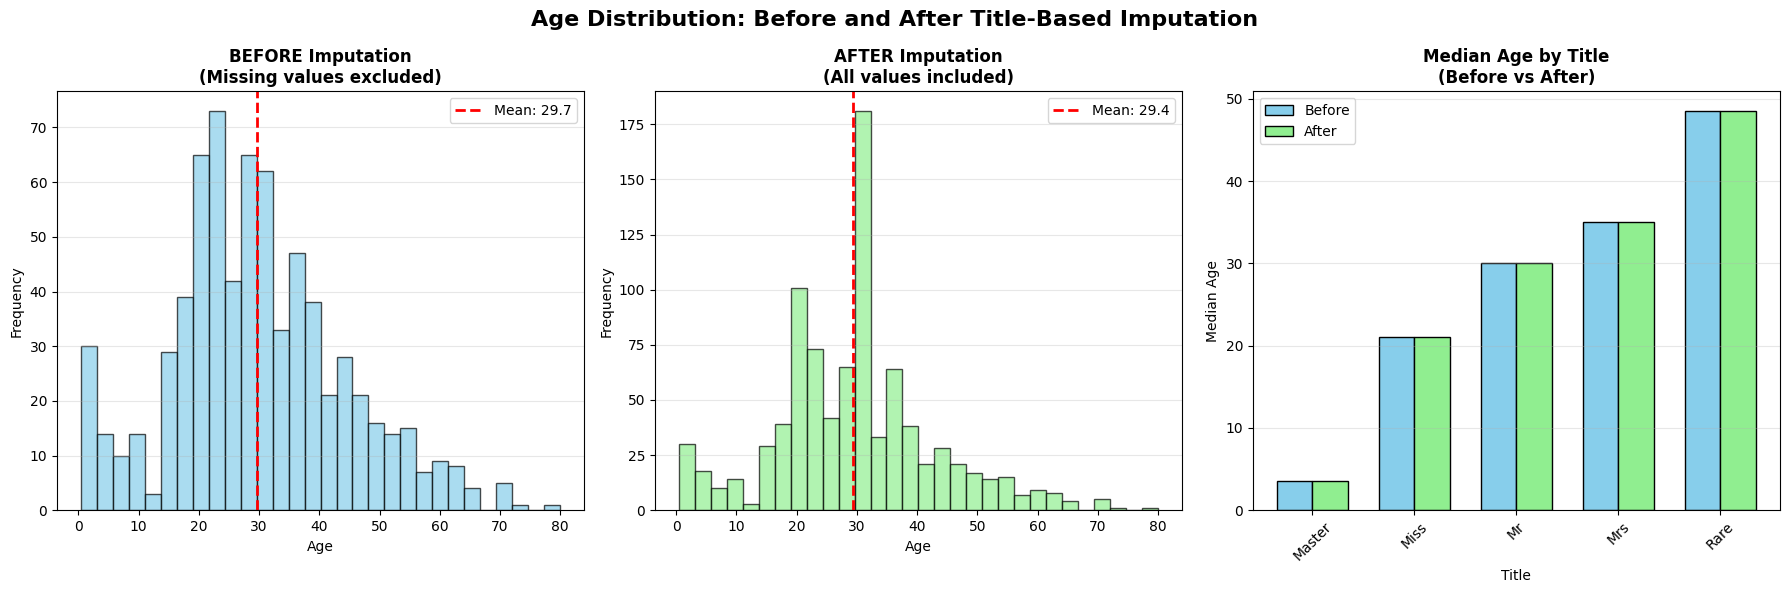


STATISTICAL COMPARISON:
 Metric  Before Imputation  After Imputation
  Count         714.000000        891.000000
Missing         177.000000          0.000000
   Mean          29.699118         29.392447
    Std          14.526497         13.268389
    Min           0.420000          0.420000
 Median          28.000000         30.000000
    Max          80.000000         80.000000

KEY OBSERVATIONS:
1. Mean age changed by: -0.31 years
2. Standard deviation changed by: -1.26 years
3. Total values: 714 → 891 (+177)
4. Distribution preserved: Yes


In [11]:
print("IMPROVED AGE IMPUTATION - TITLE-BASED METHOD")

# Check missing values BEFORE imputation
print(f"\nBEFORE IMPUTATION:")
print(f"Missing Age values: {df['Age'].isnull().sum()}")
print(f"Percentage: {df['Age'].isnull().sum() / len(df) * 100:.2f}%")

# -----------------------------
# STEP 1: Extract Title FIRST
# -----------------------------
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print("\nOriginal titles found:")
print(df['Title'].value_counts())

# Standardize rare titles
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})


df_before_imputation = df.copy()


#Calculate medians
title_median = df.groupby('Title')['Age'].median()

#Fill missing values
print("\n🔧 FILLING MISSING VALUES:")
for title in df['Title'].unique():
    median_value = title_median[title]

    mask = (df['Title'] == title) & (df['Age'].isnull())
    count_to_fill = mask.sum()

    df.loc[mask, 'Age'] = median_value

    print(f"{title:12} | Filled {count_to_fill:3} missing values with median: {median_value:.1f}")



print("\nVISUALIZING BEFORE AND AFTER:")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Age Distribution: Before and After Title-Based Imputation',
             fontsize=16, fontweight='bold')

# Plot 1: BEFORE
axes[0].hist(df_before_imputation['Age'].dropna(), bins=30,
             edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('BEFORE Imputation\n(Missing values excluded)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_before_imputation['Age'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_before_imputation["Age"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot 2: AFTER
axes[1].hist(df['Age'], bins=30,
             edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title('AFTER Imputation\n(All values included)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Age'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {df["Age"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# -----------------------------
# FIX: Safe grouping (aligned index)
# -----------------------------
title_ages_before = df_before_imputation.groupby('Title')['Age'].median()
title_ages_after = df.groupby('Title')['Age'].median()

# Align indices to avoid mismatch
title_ages_before = title_ages_before.reindex(title_ages_after.index)

titles = title_ages_after.index
x = np.arange(len(titles))
width = 0.35

# Plot 3: Comparison
axes[2].bar(x - width/2, title_ages_before.values, width,
            label='Before', color='skyblue', edgecolor='black')
axes[2].bar(x + width/2, title_ages_after.values, width,
            label='After', color='lightgreen', edgecolor='black')

axes[2].set_title('Median Age by Title\n(Before vs After)', fontweight='bold')
axes[2].set_xlabel('Title')
axes[2].set_ylabel('Median Age')
axes[2].set_xticks(x)
axes[2].set_xticklabels(titles, rotation=45)
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# -----------------------------
# STEP 6: Statistical comparison
# -----------------------------
print("\nSTATISTICAL COMPARISON:")

stats_comparison = pd.DataFrame({
    'Metric': ['Count', 'Missing', 'Mean', 'Std', 'Min', 'Median', 'Max'],
    'Before Imputation': [
        df_before_imputation['Age'].count(),
        df_before_imputation['Age'].isnull().sum(),
        df_before_imputation['Age'].mean(),
        df_before_imputation['Age'].std(),
        df_before_imputation['Age'].min(),
        df_before_imputation['Age'].median(),
        df_before_imputation['Age'].max()
    ],
    'After Imputation': [
        df['Age'].count(),
        df['Age'].isnull().sum(),
        df['Age'].mean(),
        df['Age'].std(),
        df['Age'].min(),
        df['Age'].median(),
        df['Age'].max()
    ]
})

print(stats_comparison.to_string(index=False))

# -----------------------------
# STEP 7: Observations
# -----------------------------
print("\nKEY OBSERVATIONS:")

mean_change = df['Age'].mean() - df_before_imputation['Age'].mean()
std_change = df['Age'].std() - df_before_imputation['Age'].std()

print(f"1. Mean age changed by: {mean_change:+.2f} years")
print(f"2. Standard deviation changed by: {std_change:+.2f} years")
print(f"3. Total values: {df_before_imputation['Age'].count()} → {df['Age'].count()} (+{df['Age'].count() - df_before_imputation['Age'].count()})")
print(f"4. Distribution preserved: {'Yes' if abs(std_change) < 2 else 'Partially'}")

In [12]:

df['Age'].isnull().sum() # cross-check if it worked

np.int64(0)

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) #Replacing all the missing values here with the mode
# We fill missing values with the most common category using mode as there any only 2 null values and embarked is categorical data.


In [14]:

df['Embarked'].isnull().sum() # cross-check if it worked

np.int64(0)

In [15]:

# Created– Has_Cabin before dropping — 1 if cabin was recorded, 0 if not
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)
#do not remove the column

In [16]:
df.isnull().sum() #check now if any columns are still left with missing values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## **5. EDA (Exploratory Data Analysis)**
We explore how different features relate to survival.

This helps us understand the overall outcome of the disaster.

A) Univariate Analysis

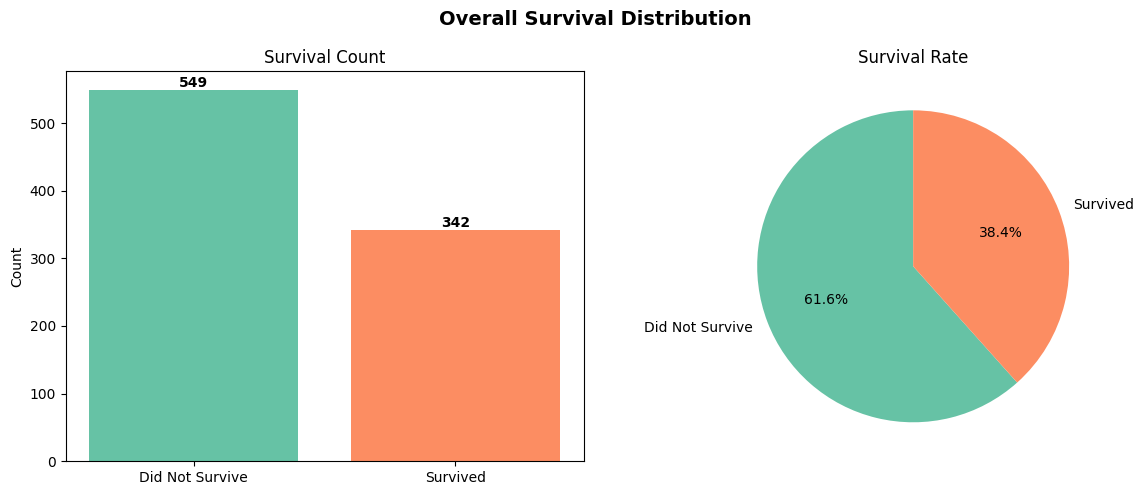

Survival Rate: 38.4%
Non-Survival Rate: 61.6%


In [17]:
# Overall survival rate
survival_counts = df['Survived'].value_counts()
survival_pct = df['Survived'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['Did Not Survive', 'Survived'], survival_counts.values,
            color=sns.color_palette('Set2')[:2])
axes[0].set_title('Survival Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survival_pct.values, labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%', colors=sns.color_palette('Set2')[:2],
            startangle=90)
axes[1].set_title('Survival Rate')

plt.suptitle('Overall Survival Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Survival Rate: {survival_pct[1]:.1f}%')
print(f'Non-Survival Rate: {survival_pct[0]:.1f}%')

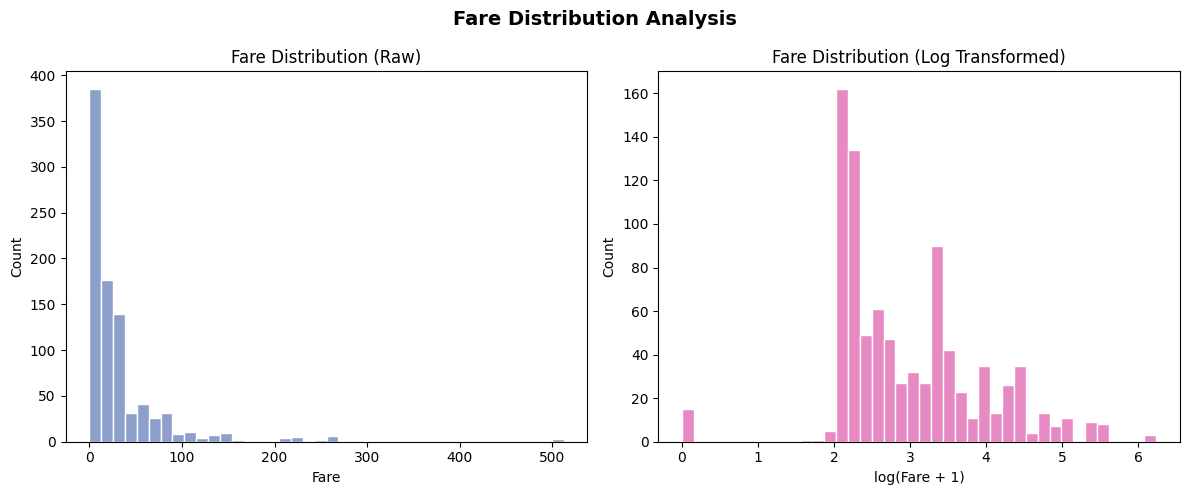

Mean Fare: $32.20
Median Fare: $14.45
Max Fare: $512.33


In [18]:
# Fare distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'], bins=40, color=sns.color_palette('Set2')[2], edgecolor='white')
axes[0].set_title('Fare Distribution (Raw)')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Fare']), bins=40, color=sns.color_palette('Set2')[3], edgecolor='white')
axes[1].set_title('Fare Distribution (Log Transformed)')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Fare Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean Fare: ${df["Fare"].mean():.2f}')
print(f'Median Fare: ${df["Fare"].median():.2f}')
print(f'Max Fare: ${df["Fare"].max():.2f}')

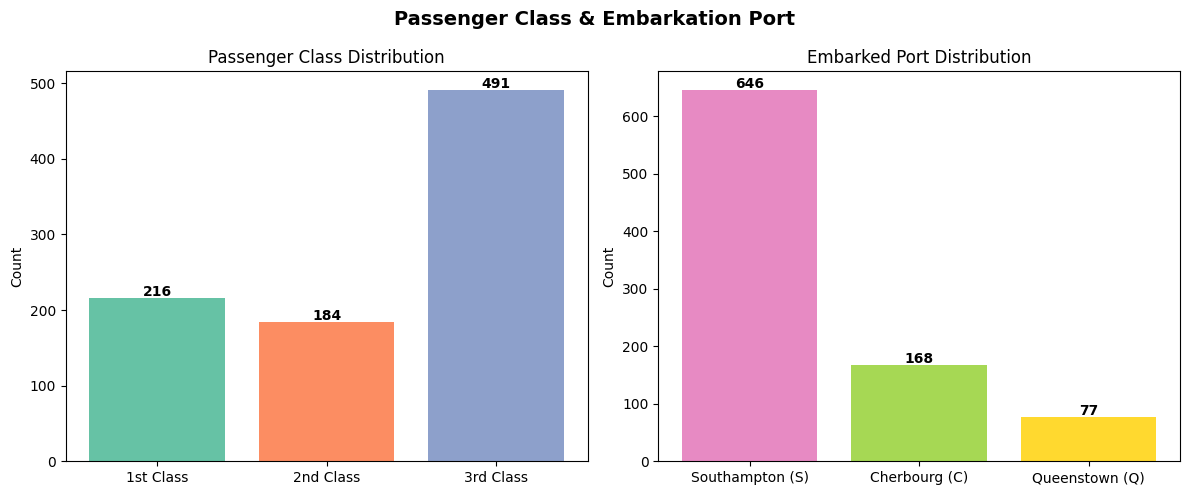

In [19]:
# Passenger class and Embarked distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0].bar(['1st Class', '2nd Class', '3rd Class'], pclass_counts.values,
            color=sns.color_palette('Set2')[:3])
axes[0].set_title('Passenger Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(pclass_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

embarked_counts = df['Embarked'].value_counts()
axes[1].bar(embarked_counts.index, embarked_counts.values,
            color=sns.color_palette('Set2')[3:6])
axes[1].set_title('Embarked Port Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)'])
for i, v in enumerate(embarked_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Passenger Class & Embarkation Port', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

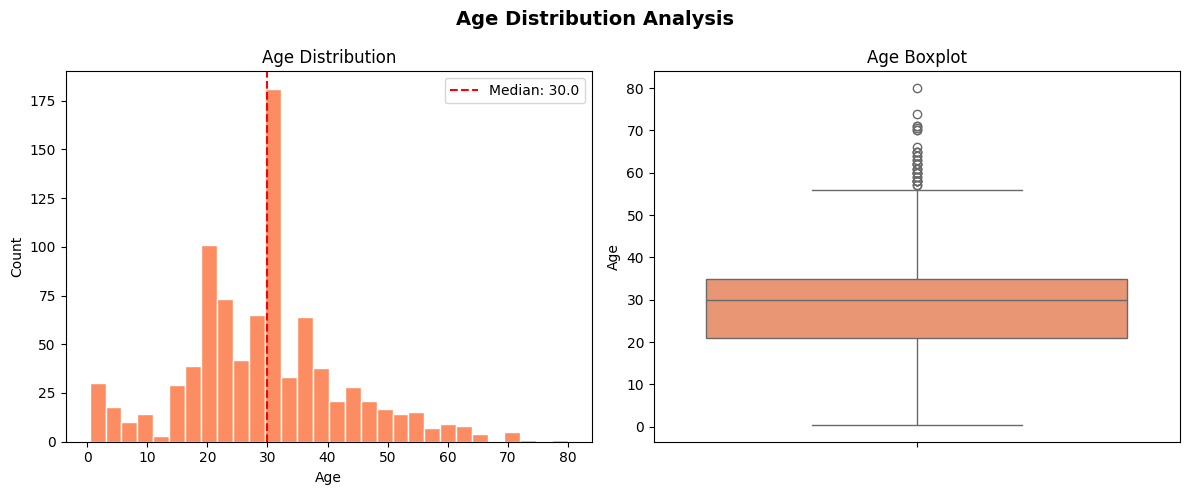

Mean Age: 29.4
Median Age: 30.0
Age Range: 0.42 - 80.0


In [20]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Age'].dropna(), bins=30, color=sns.color_palette('Set2')[1], edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median()}')
axes[0].legend()

sns.boxplot(y=df['Age'], ax=axes[1], color=sns.color_palette('Set2')[1])
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')

plt.suptitle('Age Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean Age: {df["Age"].mean():.1f}')
print(f'Median Age: {df["Age"].median()}')
print(f'Age Range: {df["Age"].min()} - {df["Age"].max()}')

(B)Bivariate Analysis

Examines the **relationship between each feature and the target variable (Survived)**.

1) Survival By Gender

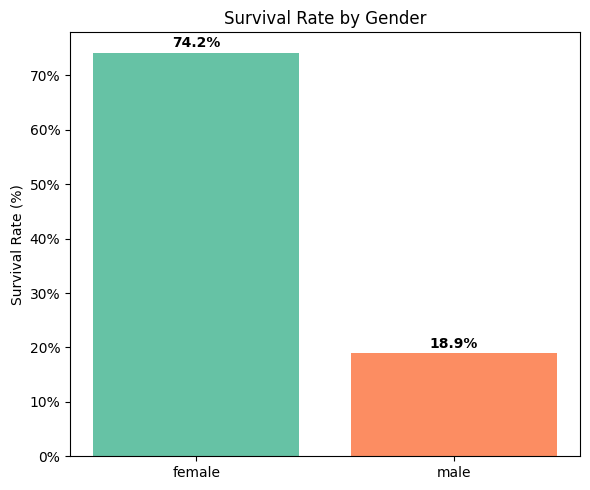

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))

gender_survival = df.groupby('Sex')['Survived'].mean() * 100
ax.bar(gender_survival.index, gender_survival.values,
       color=sns.color_palette('Set2')[:2])

ax.set_title('Survival Rate by Gender')
ax.set_ylabel('Survival Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for i, v in enumerate(gender_survival.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

2) Survival by Passenger Class

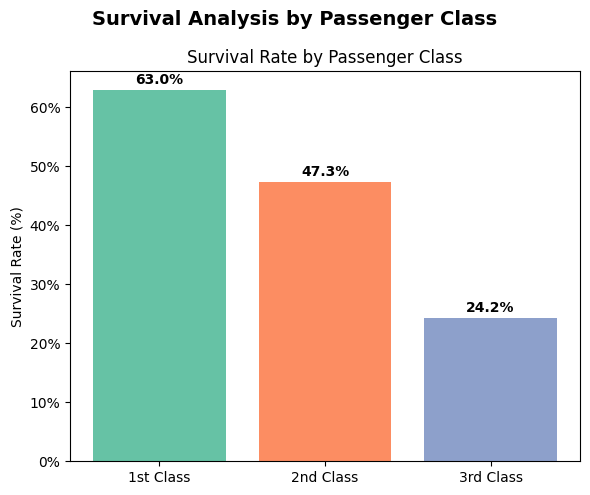

In [22]:
# Survival by passenger class
fig, ax = plt.subplots(figsize=(6, 5))

pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
ax.bar(['1st Class', '2nd Class', '3rd Class'], pclass_survival.values,
            color=sns.color_palette('Set2')[:3])
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(pclass_survival.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Survival Analysis by Passenger Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

3) Survival by Age group

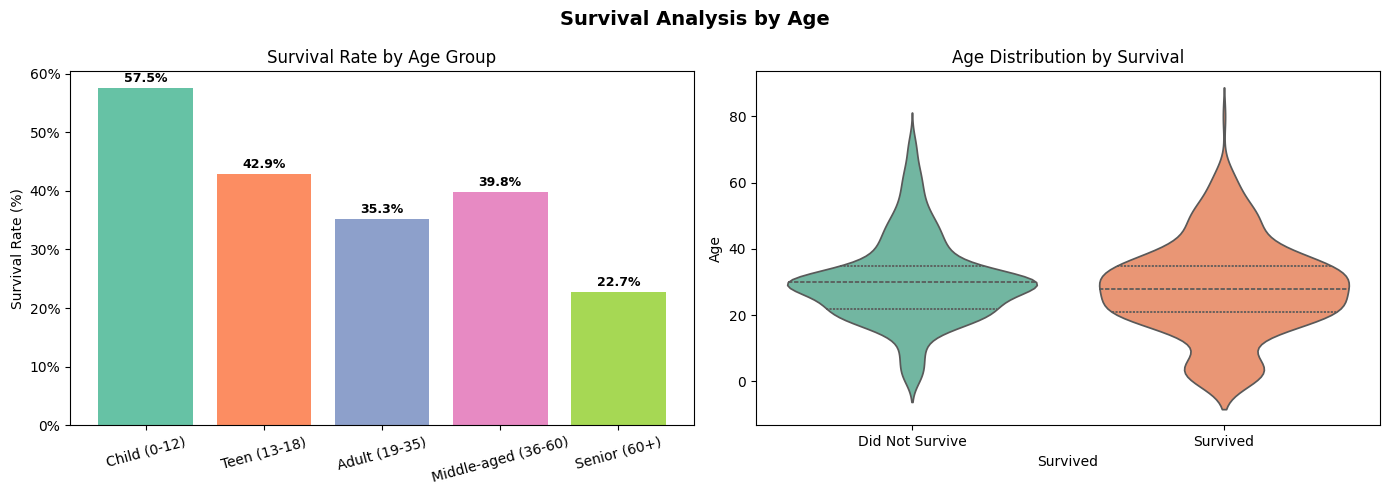

In [23]:
# Survival by age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)',
                                 'Middle-aged (36-60)', 'Senior (60+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
axes[0].bar(age_survival.index, age_survival.values,
            color=sns.color_palette('Set2', len(age_survival)))
axes[0].set_title('Survival Rate by Age Group')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(age_survival.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1],
               palette='Set2', inner='quartile')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
axes[1].set_ylabel('Age')

plt.suptitle('Survival Analysis by Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

4. Survival by 'Embarked'

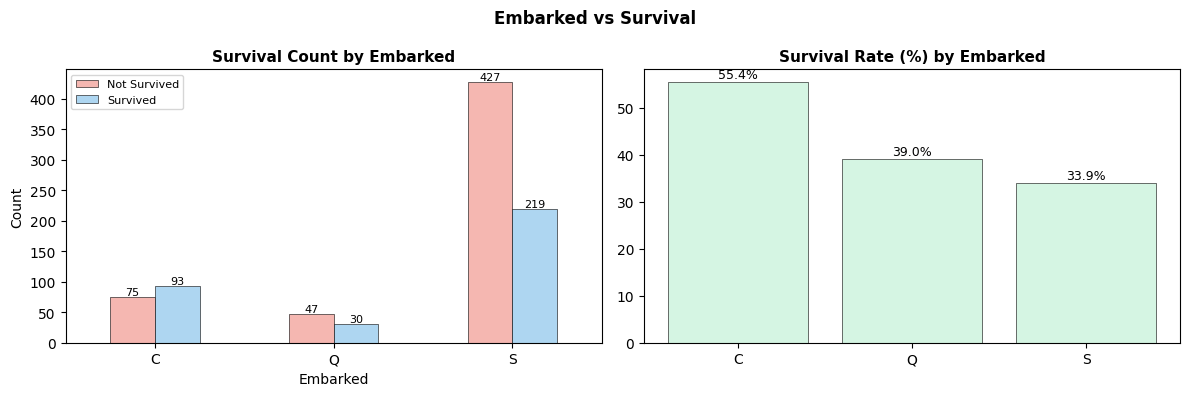

In [24]:
# Embarked vs Survival
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#f5b7b1', '#aed6f1']

# 1. Count Plot (WITH VALUES)
ct = pd.crosstab(df['Embarked'], df['Survived'])

bars = ct.plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='black',
    linewidth=0.4
)

axes[0].set_title("Survival Count by Embarked", fontsize=11, fontweight='bold')
axes[0].set_xticklabels(['C','Q','S'], rotation=0)
axes[0].set_ylabel("Count")
axes[0].legend(['Not Survived','Survived'], fontsize=8)

# ✅ Add values on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8)

# 2. Survival Rate
emb_surv = df.groupby('Embarked')['Survived'].mean() * 100

bars = axes[1].bar(['C','Q','S'], emb_surv.values,
                   color='#d5f5e3', edgecolor='black', linewidth=0.4)

axes[1].set_title("Survival Rate (%) by Embarked", fontsize=11, fontweight='bold')

for i, v in enumerate(emb_surv.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle("Embarked vs Survival", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

(C)Multivariate & Distribution Analysis

Examining **interactions between multiple variables simultaneously** reveals compound effects.

1. Survival by class and gender

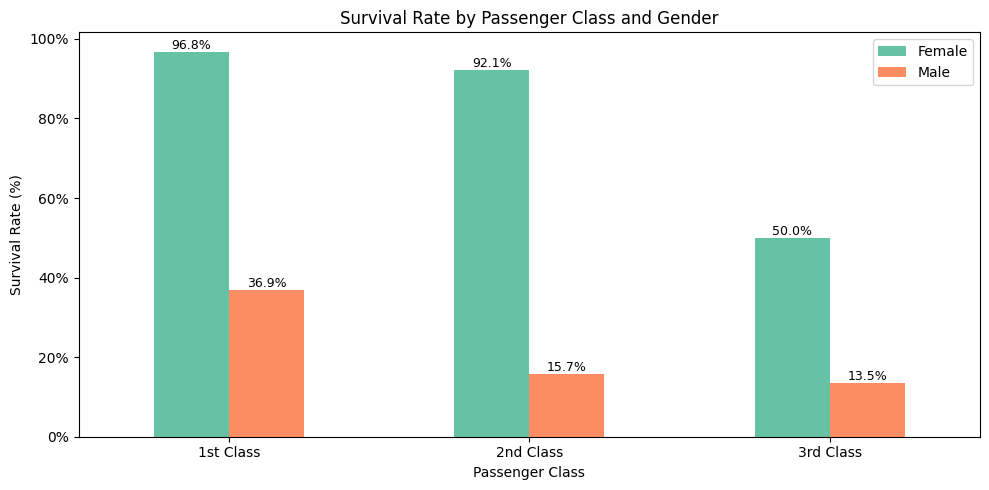

In [25]:
# Survival by class and gender
fig, ax = plt.subplots(figsize=(10, 5))

class_gender_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
bars = class_gender_survival.plot(
    kind='bar',
    ax=ax,
    color=sns.color_palette('Set2')[:2],
    rot=0
)

ax.set_title('Survival Rate by Passenger Class and Gender')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.legend(['Female', 'Male'])

# ---- Add labels on top of bars ----
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=9)

plt.tight_layout()
plt.show()

# **Key Insights**

Here are the most important findings from EDA:

##1)Gender
Women had a ~74% survival rate vs only ~19% for men

"Women and children first" policy clearly visible in the data

Gender is likely the strongest predictor of survival

##2)Passenger Class
1st class passengers had ~63% survival rate vs ~47% for 2nd class and ~24% for 3rd class

Wealthier passengers had better access to lifeboats

Pclass is a strong proxy for socioeconomic status

##3)Age
Children (0-12) had the highest survival rate among age groups

Seniors (60+) had one of the lowest survival rates

Age alone is a weaker predictor but important when combined with class and gender

##5)Fare

Higher fare strongly correlates with survival

Fare is highly skewed — log transformation brings it closer to normal distribution

Fare and Pclass are correlated — both capture wealth information

##6)Embarkation Port
Cherbourg (C) passengers had the highest survival rate (~55%)

This is likely because Cherbourg passengers were predominantly 1st class

Embarkation port is an indirect feature — its effect is mediated by class

#**6. Hypothesis Testing**


We apply **rigorous statistical tests** to determine if observed differences are statistically significant.

### Significance Level: α = 0.05
- **p < 0.05** → Reject H₀ (statistically significant)
- **p ≥ 0.05** → Fail to reject H₀

### Tests Applied
| Test | Purpose |
|------|---------|
| **Shapiro-Wilk / D'Agostino** | Normality testing |
| **Levene's Test** | Equality of variances |
| **Chi-Square** | Categorical independence |
| **Welch's t-test** | Mean difference (unequal variances) |
| **Mann-Whitney U** | Non-parametric median difference |
| **Point-Biserial** | Numerical vs binary correlation |

1) Shapiro-Wilk / D'Agostino	Normality testing

In [26]:
from scipy.stats import shapiro, normaltest

print("NORMALITY TEST\n")
print(f"{'Feature':<8} {'SW p-value':<12} {'DA p-value':<12} {'Normal?'}")

for col in ['Age', 'Fare']:
    data = df[col].dropna()

    # Shapiro (sample if large)
    sample = data.sample(min(2000, len(data)), random_state=42)
    _, p_sw = shapiro(sample)

    # D'Agostino
    _, p_da = normaltest(data)

    normal = "YES" if (p_sw > 0.05 and p_da > 0.05) else "NO"

    print(f"{col:<8} {p_sw:<12.4f} {p_da:<12.6f} {normal}")

print("\nBoth features are NOT normally distributed → use non-parametric tests")

NORMALITY TEST

Feature  SW p-value   DA p-value   Normal?
Age      0.0000       0.000000     NO
Fare     0.0000       0.000000     NO

Both features are NOT normally distributed → use non-parametric tests


2. Leven's Test

In [27]:

print("\nVARIANCE TEST (Levene)\n")
print(f"{'Feature':<8} {'p-value':<12} {'Equal Variance?'}")

for col in ['Age', 'Fare']:
    s = df[df['Survived'] == 1][col].dropna()
    ns = df[df['Survived'] == 0][col].dropna()

    _, p = levene(s, ns)
    equal = "YES" if p > 0.05 else "NO"

    print(f"{col:<8} {p:<12.4f} {equal}")

print("\nVariances are unequal → use Welch’s t-test")


VARIANCE TEST (Levene)

Feature  p-value      Equal Variance?
Age      0.0013       NO
Fare     0.0000       NO

Variances are unequal → use Welch’s t-test


3. Chi Square Test

In [28]:

print("\nCHI-SQUARE TEST (Categorical Features)\n")

for col in ['Sex', 'Pclass', 'Embarked']:
    table = pd.crosstab(df[col], df['Survived'])
    _, p, _, _ = chi2_contingency(table)

    result = "SIGNIFICANT" if p < 0.05 else "NOT significant"

    print(f"{col:<10} p-value = {p:.4f} → {result}")

print("\nSex, Pclass, Embarked significantly affect survival.")


CHI-SQUARE TEST (Categorical Features)

Sex        p-value = 0.0000 → SIGNIFICANT
Pclass     p-value = 0.0000 → SIGNIFICANT
Embarked   p-value = 0.0000 → SIGNIFICANT

Sex, Pclass, Embarked significantly affect survival.


4. Welch's T Test

In [29]:
print("\nWELCH’S t-TEST (Mean Difference)\n")
print(f"{'Feature':<8} {'t-stat':<10} {'p-value':<12} {'Significant?'}")

for col in ['Age', 'Fare']:
    s = df[df['Survived'] == 1][col].dropna()
    ns = df[df['Survived'] == 0][col].dropna()

    t, p = ttest_ind(s, ns, equal_var=False)
    sig = "YES" if p < 0.05 else "NO"

    print(f"{col:<8} {t:<10.4f} {p:<12.6f} {sig}")


WELCH’S t-TEST (Mean Difference)

Feature  t-stat     p-value      Significant?
Age      -2.3038    0.021541     YES
Fare     6.8391     0.000000     YES


5. Mann-Whitney U Test

In [30]:
print("\nMANN-WHITNEY U TEST (Non-Parametric)\n")

for col in ['Age', 'Fare']:
    s = df[df['Survived'] == 1][col].dropna()
    ns = df[df['Survived'] == 0][col].dropna()

    u, p = mannwhitneyu(s, ns, alternative='two-sided')
    sig = "YES" if p < 0.05 else "NO"

    print(f"{col:<8} U={u:.1f}  p={p:.6f} → {sig}")


MANN-WHITNEY U TEST (Non-Parametric)

Age      U=87507.5  p=0.087356 → NO
Fare     U=129951.5  p=0.000000 → YES


6. Co-relation Test (Point Biserial)

In [31]:
print("POINT-BISERIAL CORRELATION — Numerical Features vs Survived\n")
print(f"{'Feature':<10} {'r_pb':<10} {'p-value':<14} {'Direction':<12} {'Strength'}")
for col in ['Age','Fare','SibSp','Parch']:
    data = df[[col,'Survived']].dropna()
    r, p = pointbiserialr(data['Survived'], data[col])
    strength  = "Strong" if abs(r) > 0.5 else "Moderate" if abs(r) > 0.3 else "Weak" if abs(r) > 0.1 else "Negligible"
    direction = "Positive" if r > 0 else "Negative"
    sig       = "YES" if p < 0.05 else "NO"
    print(f"{col:<10} {r:<10.4f} {p:<14.6f} {direction:<12} {strength} (sig={sig})")

POINT-BISERIAL CORRELATION — Numerical Features vs Survived

Feature    r_pb       p-value        Direction    Strength
Age        -0.0789    0.018451       Negative     Negligible (sig=YES)
Fare       0.2573     0.000000       Positive     Weak (sig=YES)
SibSp      -0.0353    0.292244       Negative     Negligible (sig=NO)
Parch      0.0816     0.014799       Positive     Negligible (sig=YES)


## **Key Findings from Statistical Analysis**

- **Age and Fare are not normally distributed**, confirming the need for non-parametric methods

- **Variances are unequal** (Levene’s test) → Welch’s t-test is more appropriate than Student’s t-test


### Numerical Features

- **Fare shows a statistically significant difference** between survivors and non-survivors  
  - Supported by both Welch’s t-test and Mann-Whitney U test  
  - Effect size is **medium**, indicating a meaningful impact  

- **Age does not show a significant difference**  
  - Both parametric and non-parametric tests agree  
  - Effect size is **negligible**, indicating minimal practical importance  



### Categorical Features

- **Sex, Pclass, and Embarked are significantly associated with survival** (Chi-square test)  
  - These variables play a major role in survival outcomes  


### Correlation Insights

- **Fare has the strongest positive relationship with survival** among numerical features  
- **Age, SibSp, and Parch show weak or negligible relationships**  
  

##**7. Feature Engineering**
We create meaningful features to improve model performance.

In [32]:
# -----------------------------
# 1. Title extraction
# -----------------------------
if 'Title' not in df.columns:
    if 'Name' in df.columns:
        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

        df['Title'] = df['Title'].replace(
            ['Lady','Countess','Capt','Col','Don',
             'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
        )

        df['Title'] = df['Title'].replace(
            {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
        )
    else:
        raise ValueError("❌ 'Name' column missing and 'Title' not found.")

# -----------------------------
# 2. Family features
# -----------------------------
if 'FamilySize' not in df.columns:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

if 'IsAlone' not in df.columns:
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# -----------------------------
# 3. Fare log transform
# -----------------------------
if 'Fare_Log' not in df.columns:
    df['Fare_Log'] = np.log1p(df['Fare'])

# -----------------------------
# 4. Encode Sex (Binary)
# -----------------------------
df['Sex'] = (df['Sex'] == 'female').astype(int)

# -----------------------------
# 5. AgeGroup
# -----------------------------
if 'AgeGroup' not in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'],
                           bins=[0, 12, 20, 40, 60, 80],
                           labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])

# -----------------------------
# 6. One-hot encoding
# -----------------------------
df = pd.get_dummies(df,
                    columns=[col for col in ['Embarked', 'Title', 'AgeGroup'] if col in df.columns],
                    drop_first=True)

# -----------------------------
# 7. Drop unnecessary columns (SAFE)
# -----------------------------
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Fare'],
        inplace=True, errors='ignore')

# -----------------------------
# 8. Output
# -----------------------------
print(df.head())
print("\nFinal columns:", df.columns.tolist())

   Survived  Pclass  Sex   Age  Has_Cabin  FamilySize  IsAlone  Fare_Log  \
0         0       3    0  22.0          0           2        0  2.110213   
1         1       1    1  38.0          1           2        0  4.280593   
2         1       3    1  26.0          0           1        1  2.188856   
3         1       1    1  35.0          1           2        0  3.990834   
4         0       3    0  35.0          0           1        1  2.202765   

   Embarked_Q  Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  \
0       False        True       False      True      False       False   
1       False       False       False     False       True       False   
2       False        True        True     False      False       False   
3       False        True       False     False       True       False   
4       False        True       False      True      False       False   

   AgeGroup_Teen (13-18)  AgeGroup_Adult (19-35)  \
0                  False                    Tr

In [33]:
# Check for any issues
print("Missing values:\n", df.isnull().sum())
print("\nDataset shape:", df.shape)
print("\nSurvival distribution:\n", df['Survived'].value_counts())

Missing values:
 Survived                        0
Pclass                          0
Sex                             0
Age                             0
Has_Cabin                       0
FamilySize                      0
IsAlone                         0
Fare_Log                        0
Embarked_Q                      0
Embarked_S                      0
Title_Miss                      0
Title_Mr                        0
Title_Mrs                       0
Title_Rare                      0
AgeGroup_Teen (13-18)           0
AgeGroup_Adult (19-35)          0
AgeGroup_Middle-aged (36-60)    0
AgeGroup_Senior (60+)           0
dtype: int64

Dataset shape: (891, 18)

Survival distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


COVARIANCE AND CORRELATION ANALYSIS

UNDERSTANDING COVARIANCE VS CORRELATION:
COVARIANCE:
  → Measures how two variables change together
  → Range: -∞ to +∞
  → Problem: Scale-dependent (hard to interpret)

CORRELATION:
  → Standardized covariance (scale-independent)
  → Range: -1 to +1
  → Easier to interpret and compare

Analyzing features: ['Age', 'Pclass', 'Fare_Log', 'FamilySize']

 COVARIANCE MATRIX
                   Age    Pclass  Fare_Log  FamilySize
Age         176.050155 -3.929127  1.384297   -5.898845
Pclass       -3.929127  0.699015 -0.535555    0.089028
Fare_Log      1.384297 -0.535555  0.939055    0.599857
FamilySize   -5.898845  0.089028  0.599857    2.603248

INTERPRETATION:
Large positive values = Variables increase together
Large negative values = One increases, other decreases
Values close to 0 = Little linear relationship

PROBLEM: Hard to compare!
   Fare_Log variance: 0.94
   Age variance: 176.05
   Can't say which relationship is 'stronger' just from covariance


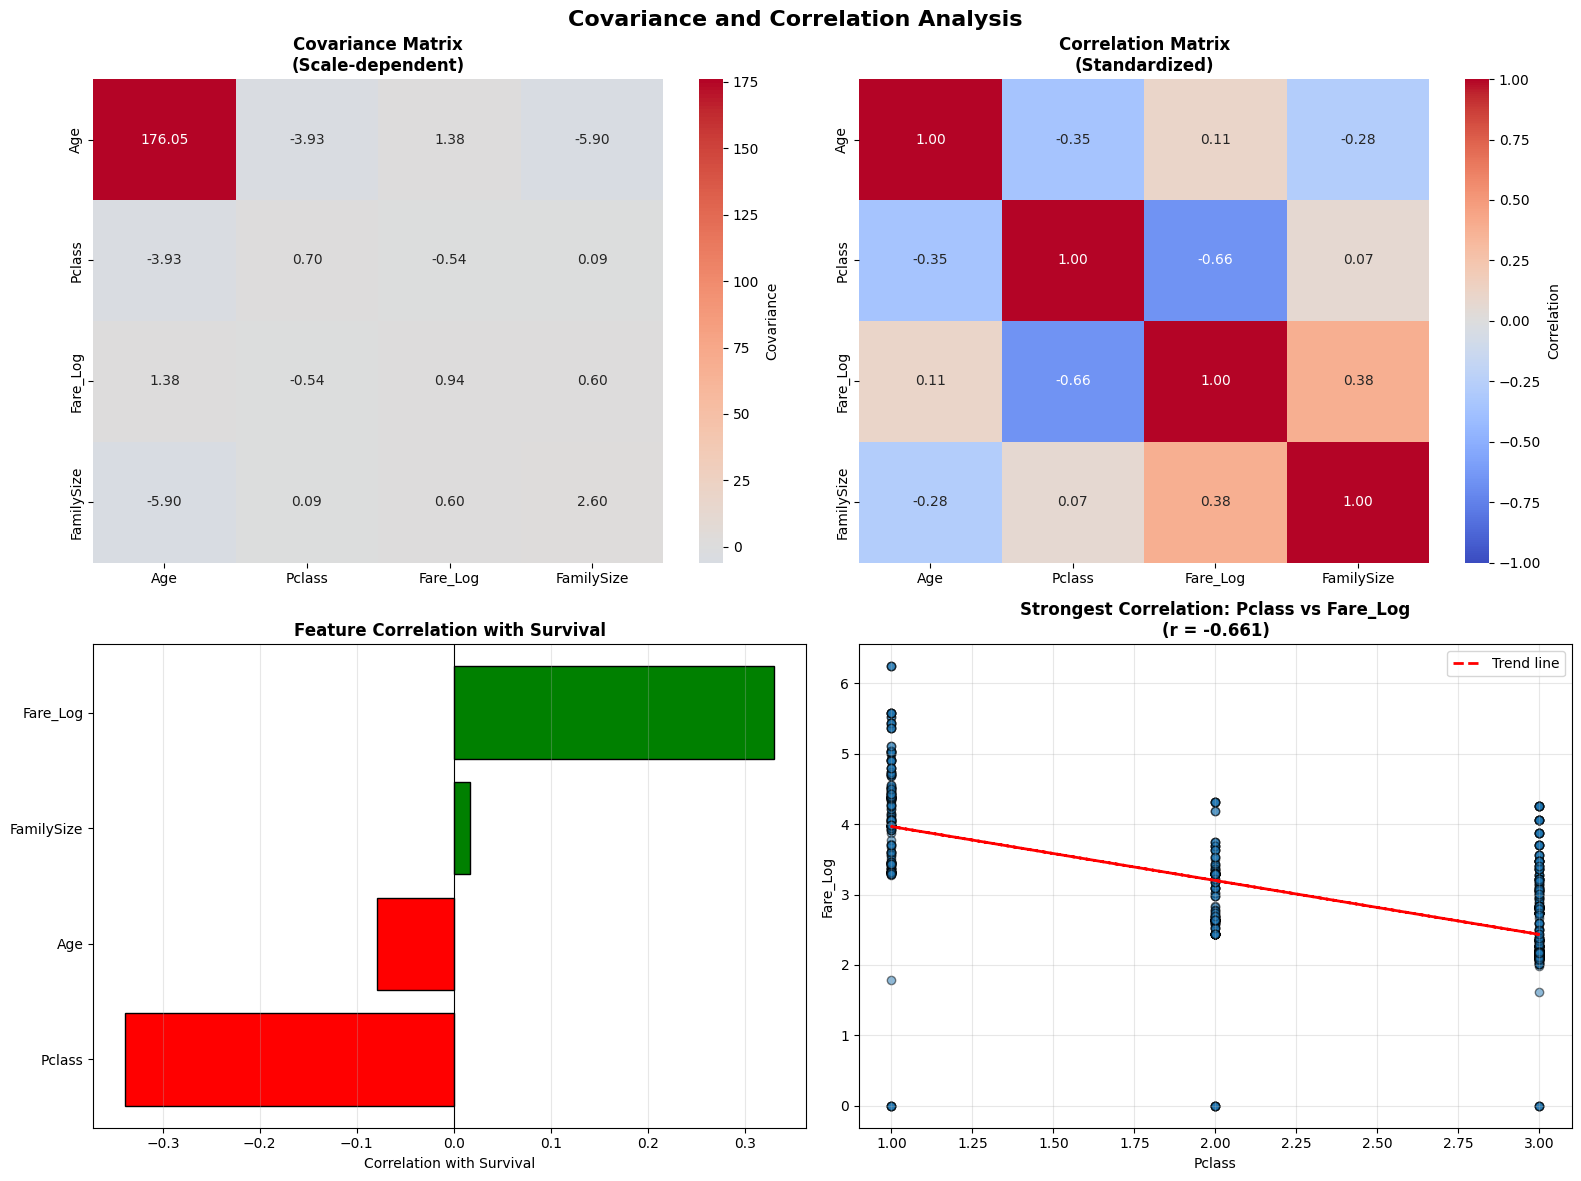


KEY INSIGHTS FROM CORRELATION ANALYSIS

STRONGEST POSITIVE CORRELATIONS:
Fare_Log     ↔ FamilySize   | r = +0.384
Age          ↔ Fare_Log     | r = +0.108
Pclass       ↔ FamilySize   | r = +0.066

STRONGEST NEGATIVE CORRELATIONS:
Pclass       ↔ Fare_Log     | r = -0.661
Age          ↔ Pclass       | r = -0.354
Age          ↔ FamilySize   | r = -0.276

CORRELATION WITH SURVIVAL:
Fare_Log     | r = +0.330 | Weak         Positive
FamilySize   | r = +0.017 | Very weak    Positive
Age          | r = -0.079 | Very weak    Negative
Pclass       | r = -0.338 | Weak         Negative
4️ MATHEMATICAL FORMULAS
Covariance formula:
  Cov(X,Y) = Σ[(Xᵢ - X̄)(Yᵢ - Ȳ)] / (n-1)
Correlation formula:
  r = Cov(X,Y) / (σₓ × σᵧ)
  Where σₓ and σᵧ are standard deviations
Relationship:
  Correlation = Standardized Covariance
  r always between -1 and +1


In [34]:
print("COVARIANCE AND CORRELATION ANALYSIS")

print("\nUNDERSTANDING COVARIANCE VS CORRELATION:")
print("COVARIANCE:")
print("  → Measures how two variables change together")
print("  → Range: -∞ to +∞")
print("  → Problem: Scale-dependent (hard to interpret)")
print("")
print("CORRELATION:")
print("  → Standardized covariance (scale-independent)")
print("  → Range: -1 to +1")
print("  → Easier to interpret and compare")

# Select numerical features for analysis
numerical_features = ['Age', 'Pclass', 'Fare_Log', 'FamilySize', 'SibSp', 'Parch']
# Note: Include original features before one-hot encoding for better interpretation

# If you already dropped SibSp/Parch, use available features
available_numerical = [col for col in numerical_features if col in df.columns]
print(f"\nAnalyzing features: {available_numerical}")

# 1. COVARIANCE MATRIX
print("\n" + "=" * 80)
print(" COVARIANCE MATRIX")

cov_matrix = df[available_numerical].cov()
print(cov_matrix)

print("\nINTERPRETATION:")

print("Large positive values = Variables increase together")
print("Large negative values = One increases, other decreases")
print("Values close to 0 = Little linear relationship")
print("\nPROBLEM: Hard to compare!")
print(f"   Fare_Log variance: {cov_matrix.loc['Fare_Log', 'Fare_Log']:.2f}")
print(f"   Age variance: {cov_matrix.loc['Age', 'Age']:.2f}")
print("   Can't say which relationship is 'stronger' just from covariance")

# 2. CORRELATION MATRIX
print("CORRELATION MATRIX (Pearson)")

corr_matrix = df[available_numerical].corr()
print(corr_matrix)

print("\nINTERPRETATION GUIDE:")

print("|r| = 0.00-0.19 → Very weak")
print("|r| = 0.20-0.39 → Weak")
print("|r| = 0.40-0.59 → Moderate")
print("|r| = 0.60-0.79 → Strong")
print("|r| = 0.80-1.00 → Very strong")

# 3. VISUALIZATIONS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Covariance and Correlation Analysis', fontsize=16, fontweight='bold')

# 3a. Covariance Heatmap
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0, 0], cbar_kws={'label': 'Covariance'})
axes[0, 0].set_title('Covariance Matrix\n(Scale-dependent)', fontweight='bold')

# 3b. Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0, 1], cbar_kws={'label': 'Correlation'})
axes[0, 1].set_title('Correlation Matrix\n(Standardized)', fontweight='bold')

# 3c. Correlation with Survived
if 'Survived' in df.columns:
    survival_corr = df[available_numerical + ['Survived']].corr()['Survived'].drop('Survived').sort_values()
    colors = ['red' if x < 0 else 'green' for x in survival_corr.values]
    axes[1, 0].barh(survival_corr.index, survival_corr.values, color=colors, edgecolor='black')
    axes[1, 0].set_xlabel('Correlation with Survival')
    axes[1, 0].set_title('Feature Correlation with Survival', fontweight='bold')
    axes[1, 0].axvline(0, color='black', linewidth=0.8)
    axes[1, 0].grid(alpha=0.3, axis='x')

# 3d. Scatter plot of strongest correlation
# Find strongest correlation (excluding diagonal)
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, 0)
max_corr_idx = np.unravel_index(np.abs(corr_no_diag).values.argmax(), corr_no_diag.shape)
feat1 = corr_no_diag.index[max_corr_idx[0]]
feat2 = corr_no_diag.columns[max_corr_idx[1]]
corr_value = corr_no_diag.iloc[max_corr_idx[0], max_corr_idx[1]]

axes[1, 1].scatter(df[feat1], df[feat2], alpha=0.5, edgecolor='black')
axes[1, 1].set_xlabel(feat1)
axes[1, 1].set_ylabel(feat2)
axes[1, 1].set_title(f'Strongest Correlation: {feat1} vs {feat2}\n(r = {corr_value:.3f})', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df[feat1], df[feat2], 1)
p = np.poly1d(z)
axes[1, 1].plot(df[feat1], p(df[feat1]), "r--", linewidth=2, label='Trend line')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 4. DETAILED INSIGHTS
print("\n" + "=" * 80)
print("KEY INSIGHTS FROM CORRELATION ANALYSIS")

# Find strongest positive and negative correlations
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Feature 1': corr_matrix.index[i],
            'Feature 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print("\nSTRONGEST POSITIVE CORRELATIONS:")
positive_corr = corr_pairs_df[corr_pairs_df['Correlation'] > 0].head(5)
for idx, row in positive_corr.iterrows():
    print(f"{row['Feature 1']:12} ↔ {row['Feature 2']:12} | r = {row['Correlation']:+.3f}")
    if abs(row['Correlation']) > 0.7:
        print(f"  ⚠️ HIGH CORRELATION - Consider removing one feature (multicollinearity risk)")

print("\nSTRONGEST NEGATIVE CORRELATIONS:")
negative_corr = corr_pairs_df[corr_pairs_df['Correlation'] < 0].head(5)
for idx, row in negative_corr.iterrows():
    print(f"{row['Feature 1']:12} ↔ {row['Feature 2']:12} | r = {row['Correlation']:+.3f}")

# Correlation with target (if available)
if 'Survived' in df.columns:
    print("\nCORRELATION WITH SURVIVAL:")
    survival_corr_sorted = df[available_numerical + ['Survived']].corr()['Survived'].drop('Survived').sort_values(ascending=False)
    for feat, corr_val in survival_corr_sorted.items():
        strength = (
            "Very weak" if abs(corr_val) < 0.2 else
            "Weak" if abs(corr_val) < 0.4 else
            "Moderate" if abs(corr_val) < 0.6 else
            "Strong" if abs(corr_val) < 0.8 else
            "Very strong"
        )
        direction = "Positive" if corr_val > 0 else "Negative"
        print(f"{feat:12} | r = {corr_val:+.3f} | {strength:12} {direction}")

print("4️ MATHEMATICAL FORMULAS")
print("Covariance formula:")
print("  Cov(X,Y) = Σ[(Xᵢ - X̄)(Yᵢ - Ȳ)] / (n-1)")
print("Correlation formula:")
print("  r = Cov(X,Y) / (σₓ × σᵧ)")
print("  Where σₓ and σᵧ are standard deviations")
print("Relationship:")
print("  Correlation = Standardized Covariance")
print("  r always between -1 and +1")

##**8.Train-Test Split**
Data is split into training and testing sets (80-20) using stratification.

In [35]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keeps same survival ratio in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (712, 17)
Test set: (179, 17)


In [36]:
print(X.dtypes)

Pclass                            int64
Sex                               int64
Age                             float64
Has_Cabin                         int64
FamilySize                        int64
IsAlone                           int64
Fare_Log                        float64
Embarked_Q                         bool
Embarked_S                         bool
Title_Miss                         bool
Title_Mr                           bool
Title_Mrs                          bool
Title_Rare                         bool
AgeGroup_Teen (13-18)              bool
AgeGroup_Adult (19-35)             bool
AgeGroup_Middle-aged (36-60)       bool
AgeGroup_Senior (60+)              bool
dtype: object


## **9.Model Strategy**

We evaluate three models:

1. Logistic Regression — interpretable baseline  model
2. Random Forest — handles non-linearity  
3. XGBoost — boosting-based high-performance model  

Goal: Identify the best-performing model

##**10. Models Training**

In [37]:

# MODEL 1: RANDOM FOREST (NO SCALING NEEDED)
print("RANDOM FOREST")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {rf_acc:.4f}\n")

# MODEL 2: LOGISTIC REGRESSION
print("LOGISTIC REGRESSION")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Accuracy: {lr_acc:.4f}\n")

# MODEL 3: XGBOOST
print("XGBOOST")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"Accuracy: {xgb_acc:.4f}\n")

# COMPARISON
print("MODEL COMPARISON")
print(f"Random Forest:       {rf_acc:.4f}")
print(f"Logistic Regression: {lr_acc:.4f}")
print(f"XGBoost:             {xgb_acc:.4f}")

RANDOM FOREST
Accuracy: 0.8045

LOGISTIC REGRESSION
Accuracy: 0.8436

XGBOOST
Accuracy: 0.8101

MODEL COMPARISON
Random Forest:       0.8045
Logistic Regression: 0.8436
XGBoost:             0.8101


##**11. Model Evaluation**


LOGISTIC REGRESSION - EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Survived       0.87      0.87      0.87       110
    Survived       0.80      0.80      0.80        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


CONFUSION MATRIX
                 Pred Died  Pred Survived
Actual Died             96             14
Actual Survived         14             55

Correctly predicted deaths: 96
Correctly predicted survivals: 55
False positives: 14
False negatives: 14


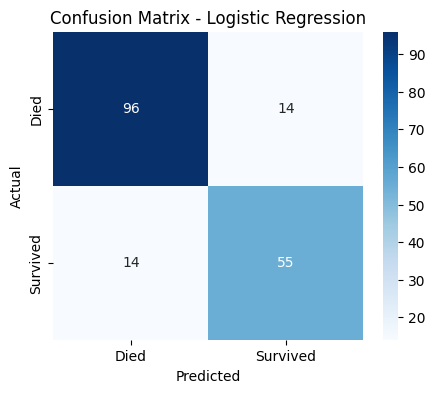


RANDOM FOREST - EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


CONFUSION MATRIX
                 Pred Died  Pred Survived
Actual Died             97             13
Actual Survived         22             47

Correctly predicted deaths: 97
Correctly predicted survivals: 47
False positives: 13
False negatives: 22


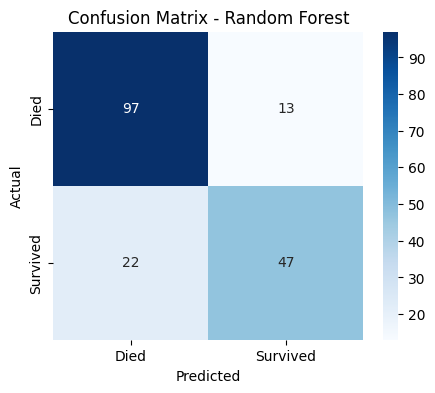


XGBOOST - EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Survived       0.82      0.88      0.85       110
    Survived       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


CONFUSION MATRIX
                 Pred Died  Pred Survived
Actual Died             97             13
Actual Survived         21             48

Correctly predicted deaths: 97
Correctly predicted survivals: 48
False positives: 13
False negatives: 21


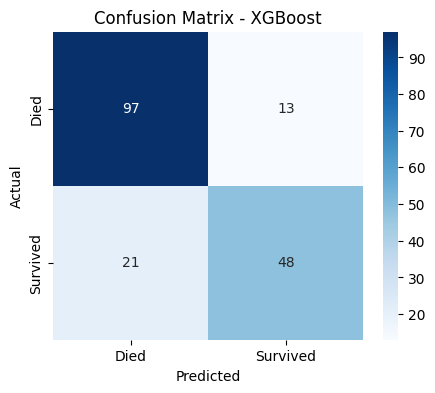

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    print("\n" + "="*60)
    print(f"{name.upper()} - EVALUATION")
    print("="*60)

    # Classification Report
    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, pred, target_names=['Not Survived', 'Survived']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)

    print("\nCONFUSION MATRIX")
    print(pd.DataFrame(cm,
          index=['Actual Died','Actual Survived'],
          columns=['Pred Died','Pred Survived']))

    print(f"\nCorrectly predicted deaths: {cm[0,0]}")
    print(f"Correctly predicted survivals: {cm[1,1]}")
    print(f"False positives: {cm[0,1]}")
    print(f"False negatives: {cm[1,0]}")

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

##**12.Cross Validation**

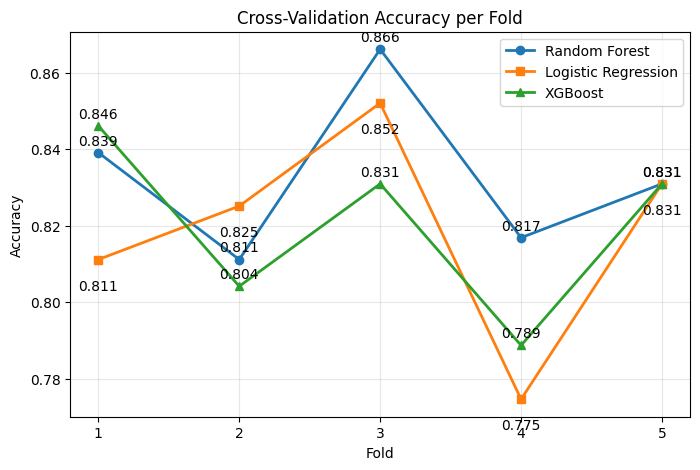


CROSS-VALIDATION SUMMARY
Random Forest       : 0.8329 ± 0.0194
Logistic Regression : 0.8188 ± 0.0257
XGBoost             : 0.8202 ± 0.0207


In [39]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------
# CROSS-VALIDATION
# -------------------------------

rf_cv = cross_validate(rf, X_train, y_train, cv=skf, scoring='accuracy')
lr_cv = cross_validate(lr, X_train_scaled, y_train, cv=skf, scoring='accuracy')
xgb_cv = cross_validate(xgb, X_train, y_train, cv=skf, scoring='accuracy')

# -------------------------------
# EXTRACT ACCURACY
# -------------------------------

rf_acc = rf_cv['test_score']
lr_acc = lr_cv['test_score']
xgb_acc = xgb_cv['test_score']

folds = np.arange(1, 6)

# -------------------------------
# PLOT
# -------------------------------

plt.figure(figsize=(8,5))

plt.plot(folds, rf_acc, marker='o', linewidth=2, label='Random Forest')
plt.plot(folds, lr_acc, marker='s', linewidth=2, label='Logistic Regression')
plt.plot(folds, xgb_acc, marker='^', linewidth=2, label='XGBoost')

for i in range(len(folds)):
    plt.text(folds[i], rf_acc[i] + 0.002, f"{rf_acc[i]:.3f}", ha='center')
    plt.text(folds[i], lr_acc[i] - 0.008, f"{lr_acc[i]:.3f}", ha='center')
    plt.text(folds[i], xgb_acc[i] + 0.002, f"{xgb_acc[i]:.3f}", ha='center')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy per Fold")
plt.xticks(folds)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# -------------------------------
# SUMMARY
# -------------------------------

print("\nCROSS-VALIDATION SUMMARY")
print(f"Random Forest       : {rf_acc.mean():.4f} ± {rf_acc.std():.4f}")
print(f"Logistic Regression : {lr_acc.mean():.4f} ± {lr_acc.std():.4f}")
print(f"XGBoost             : {xgb_acc.mean():.4f} ± {xgb_acc.std():.4f}")

## Cross-Validation Accuracy per Fold

### What this plot shows
- Accuracy of each model across 5 different folds
- Helps understand consistency, stability, and sensitivity to data splits

---

### Key Observations

#### Random Forest
- Most consistent performer overall
- Achieved highest accuracy (0.866) in Fold 3
- Moderate variation across folds → relatively stable

#### Logistic Regression
- Shows noticeable fluctuation across folds
- Performs well in Fold 3 (0.852)
- Drops significantly in Fold 4 (0.775)
- Less stable compared to Random Forest

#### XGBoost
- Starts strong (0.846), dips in middle folds
- Lowest at Fold 4 (0.789), recovers in Fold 5 (0.831)
- Moderately stable

---

### Model Stability Comparison

- Most stable: Random Forest  
- Moderately stable: XGBoost  
- Least stable: Logistic Regression  

---

### Fold-wise Insight

- Fold 3: Best performance across all models  
- Fold 4: Worst-performing fold → likely a harder data split  
- Shows why cross-validation is important

---

### Key Takeaway

A good model should not only perform well but also remain consistent across different data splits.

Random Forest shows the best balance of accuracy and stability.

##**13.ROC-AUC**

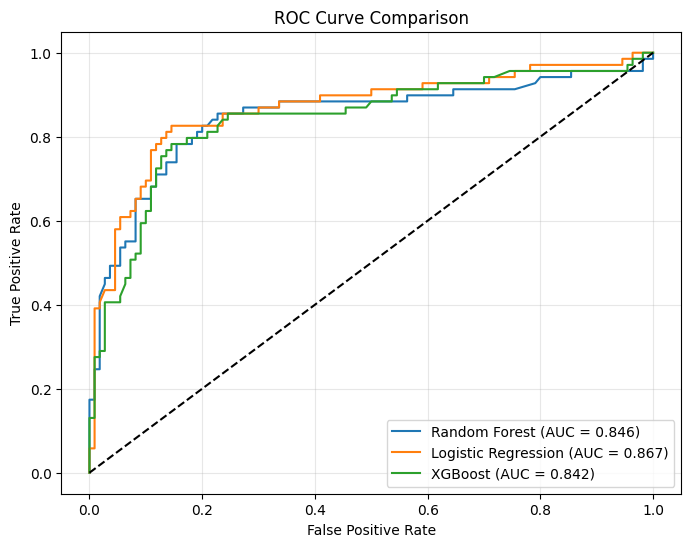

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
rf_proba = rf.predict_proba(X_test)[:, 1]
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# ROC values
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

# AUC scores
rf_auc = roc_auc_score(y_test, rf_proba)
lr_auc = roc_auc_score(y_test, lr_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Diagonal (random model)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Model Selection

Although Random Forest showed slightly higher cross-validation accuracy,
Logistic Regression was selected because:

- Highest test accuracy (0.8436)
- Best ROC-AUC (0.867)
- Balanced precision and recall
- Minimal overfitting

Therefore, Logistic Regression demonstrates the best generalization ability.

Hence, further optimization (threshold tuning) is performed on Logistic Regression.

OPTIMAL THRESHOLD RESULTS
Optimal Threshold: 0.4382
Recall (TPR): 0.8261
False Positive Rate: 0.1455
Youden’s J Score: 0.6806

THRESHOLD COMPARISON

Default Threshold (0.5)
Accuracy : 0.8436
Precision: 0.7971
Recall   : 0.7971
F1 Score : 0.7971

Optimal Threshold (0.438)
Accuracy : 0.8436
Precision: 0.7808
Recall   : 0.8261
F1 Score : 0.8028


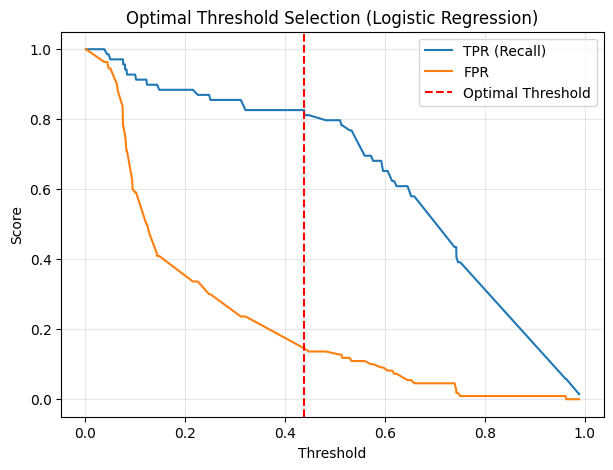

In [41]:
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Get predicted probabilities
# -----------------------------------
probs = lr.predict_proba(X_test_scaled)[:, 1]

# -----------------------------------
# 2. Compute ROC values
# -----------------------------------
fpr, tpr, thresholds = roc_curve(y_test, probs)

# -----------------------------------
# 3. Youden’s J Statistic
# -----------------------------------
j_scores = tpr - fpr
best_index = np.argmax(j_scores)

optimal_threshold = thresholds[best_index]

print("OPTIMAL THRESHOLD RESULTS")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Recall (TPR): {tpr[best_index]:.4f}")
print(f"False Positive Rate: {fpr[best_index]:.4f}")
print(f"Youden’s J Score: {j_scores[best_index]:.4f}")

# -----------------------------------
# 4. Predictions using optimal threshold
# -----------------------------------
y_pred_opt = (probs >= optimal_threshold).astype(int)

# -----------------------------------
# 5. Compare with default threshold (0.5)
# -----------------------------------
y_pred_default = (probs >= 0.5).astype(int)

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

print("\nTHRESHOLD COMPARISON")
evaluate(y_test, y_pred_default, "Default Threshold (0.5)")
evaluate(y_test, y_pred_opt, f"Optimal Threshold ({optimal_threshold:.3f})")

# -----------------------------------
# 6. Threshold vs TPR/FPR Plot
# -----------------------------------
plt.figure(figsize=(7,5))
plt.plot(thresholds, tpr, label="TPR (Recall)")
plt.plot(thresholds, fpr, label="FPR")
plt.axvline(optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimal Threshold Selection (Logistic Regression)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
thresholds_to_test = [0.3, 0.5, optimal_threshold, 0.7]

print("\nDETAILED THRESHOLD COMPARISON")
print("Threshold | Accuracy | Precision | Recall | F1")

for t in thresholds_to_test:
    pred = (probs >= t).astype(int)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"{t:.3f}     | {acc:.4f}  | {prec:.4f}   | {rec:.4f} | {f1:.4f}")


DETAILED THRESHOLD COMPARISON
Threshold | Accuracy | Precision | Recall | F1
0.300     | 0.7877  | 0.6782   | 0.8551 | 0.7564
0.500     | 0.8436  | 0.7971   | 0.7971 | 0.7971
0.438     | 0.8436  | 0.7808   | 0.8261 | 0.8028
0.700     | 0.7821  | 0.8750   | 0.5072 | 0.6422


##**14.Model Interpretation**

                         Feature  Coefficient  Odds_Ratio
1                            Sex     0.584483    1.794064
6                       Fare_Log     0.404444    1.498469
3                      Has_Cabin     0.376856    1.457695
7                     Embarked_Q     0.087712    1.091673
11                     Title_Mrs     0.070386    1.072922
5                        IsAlone    -0.047438    0.953669
16         AgeGroup_Senior (60+)    -0.047782    0.953341
15  AgeGroup_Middle-aged (36-60)    -0.108841    0.896873
8                     Embarked_S    -0.124528    0.882914
14        AgeGroup_Adult (19-35)    -0.177398    0.837446
13         AgeGroup_Teen (13-18)    -0.178450    0.836566
12                    Title_Rare    -0.223272    0.799897
9                     Title_Miss    -0.330407    0.718631
0                         Pclass    -0.453482    0.635412
2                            Age    -0.493563    0.610448
4                     FamilySize    -0.825710    0.437924
10            

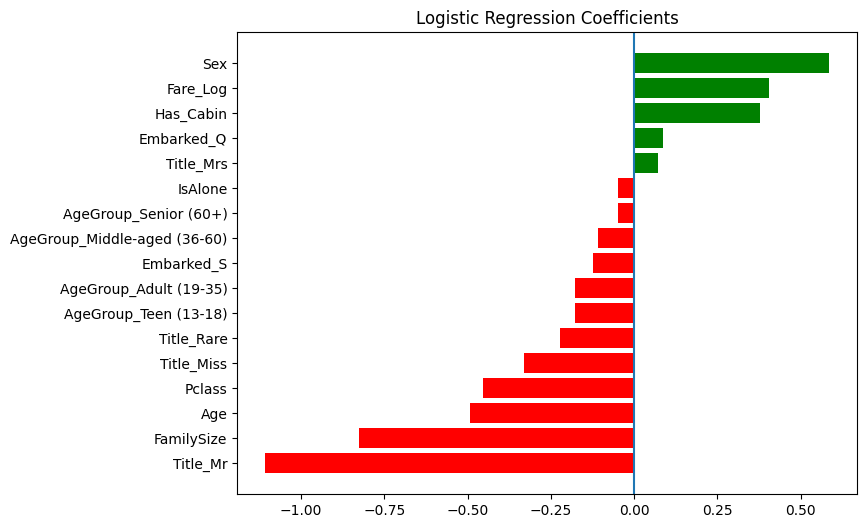

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Odds ratio
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df)

# interpretation column
coef_df['Impact'] = coef_df['Coefficient'].apply(
    lambda x: 'Increases Survival' if x > 0 else 'Decreases Survival'
)

# Plot
plt.figure(figsize=(8,6))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0)
plt.title("Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()


SHAP - Random Forest


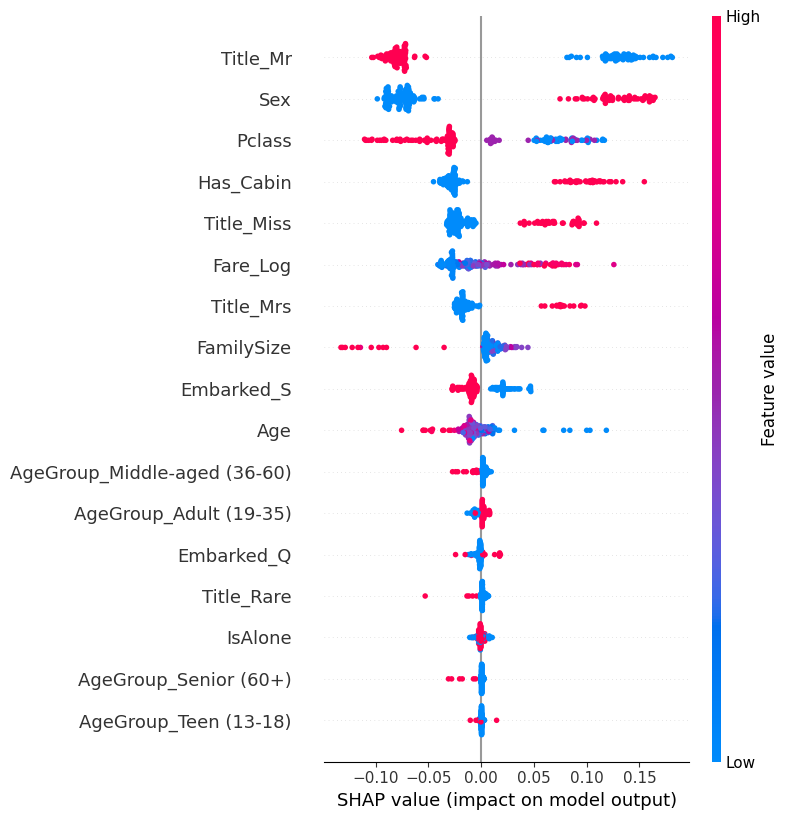

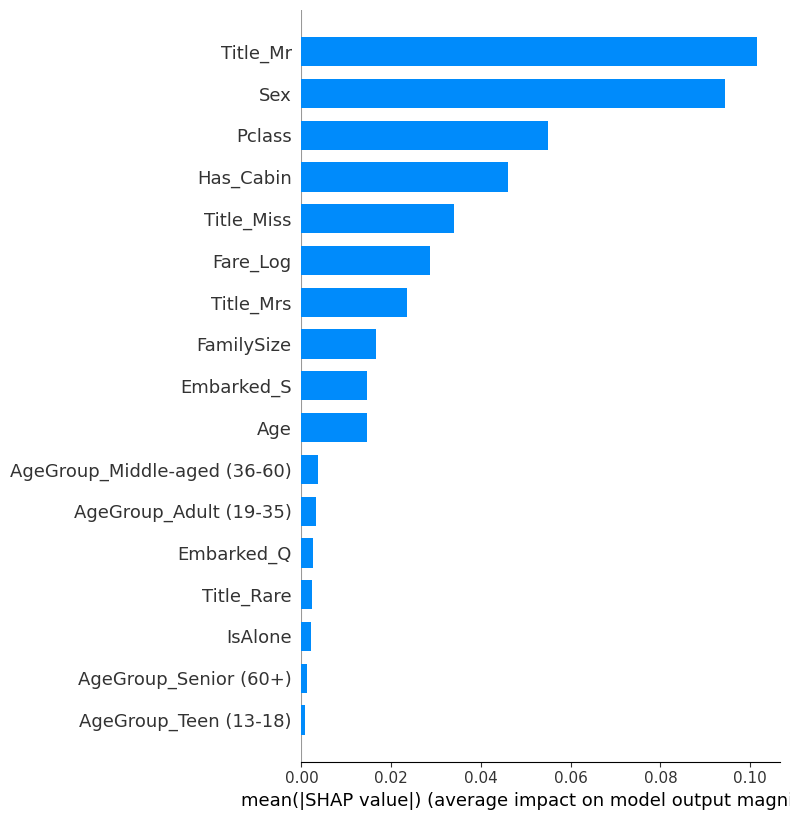

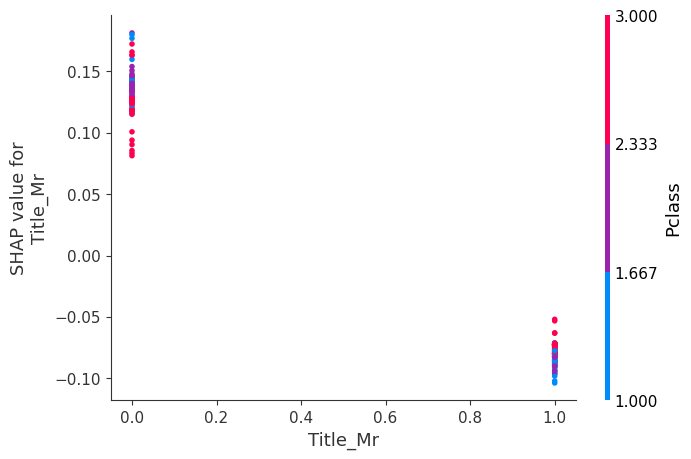

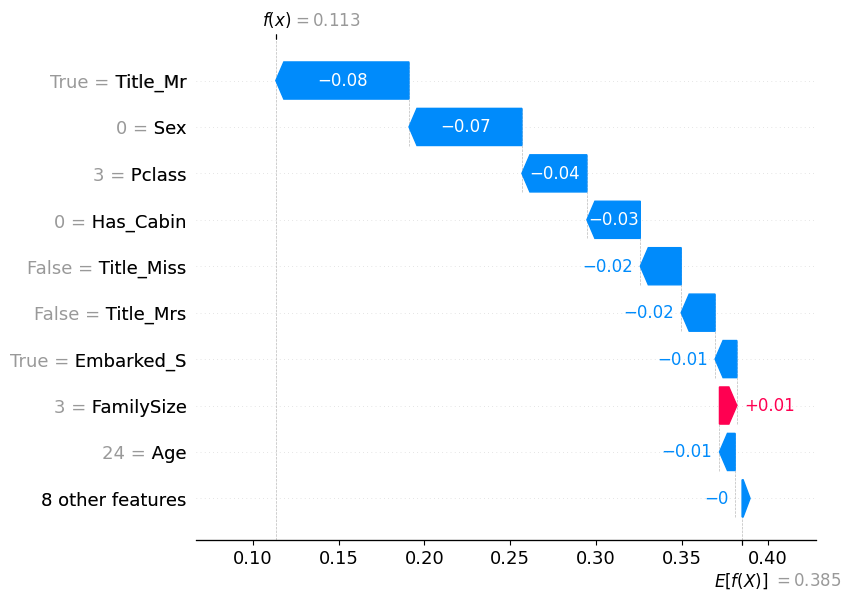


SHAP - XGBoost


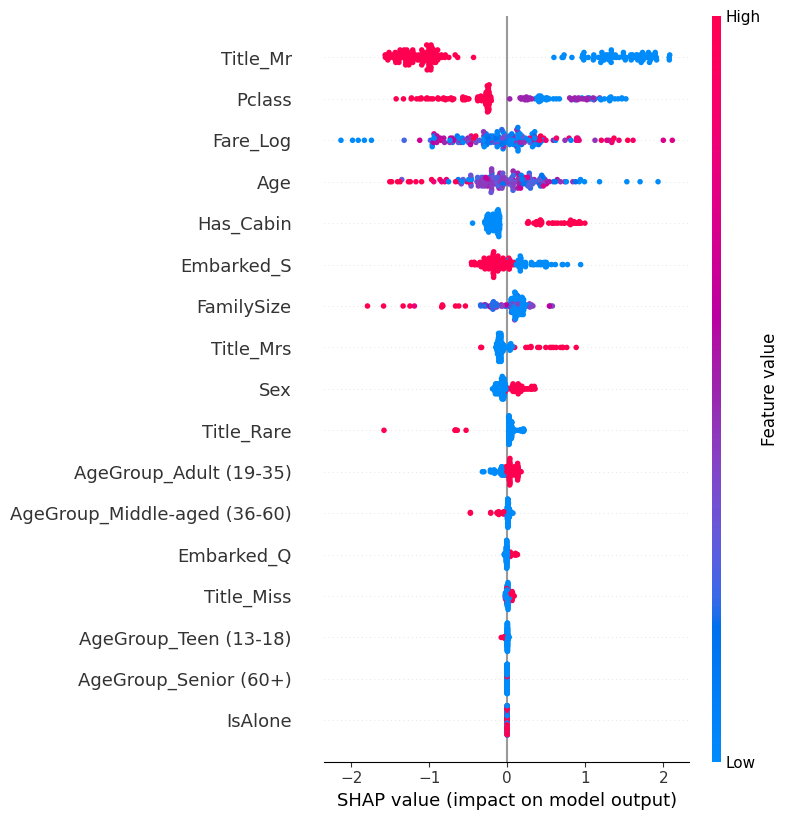

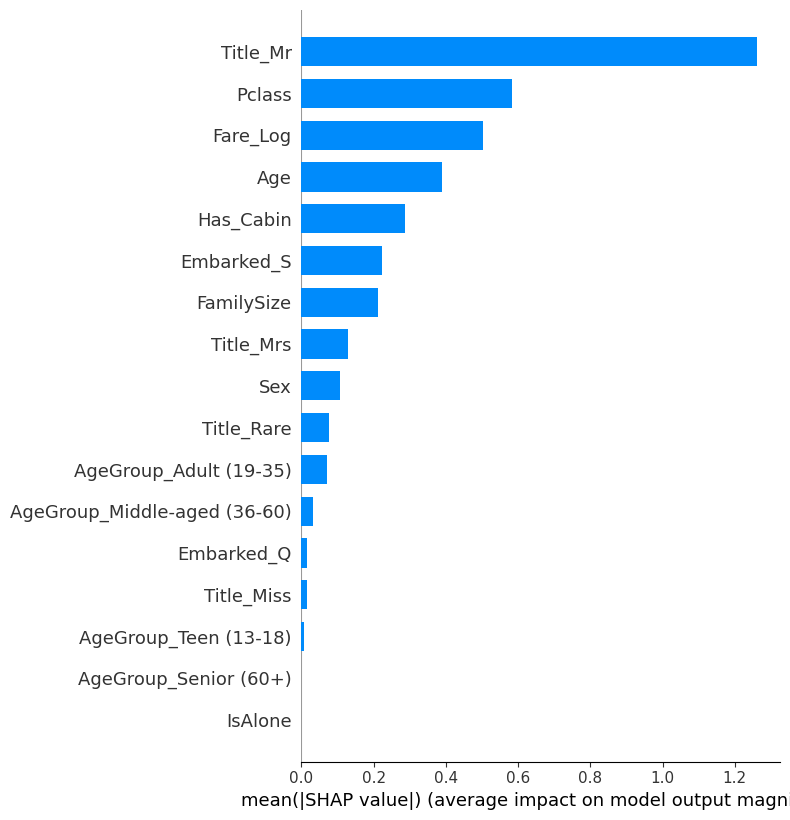

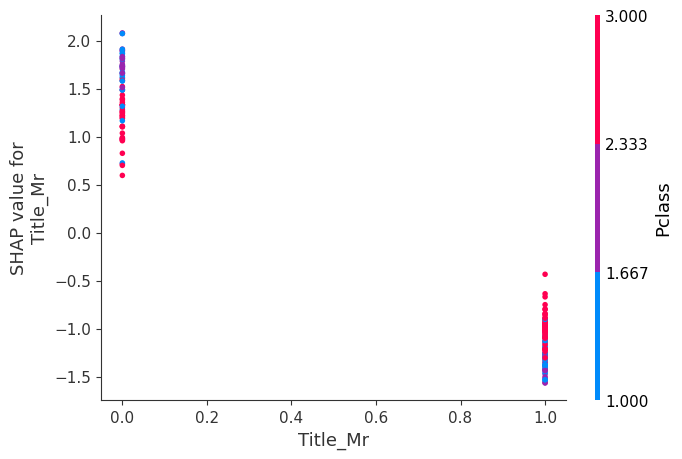

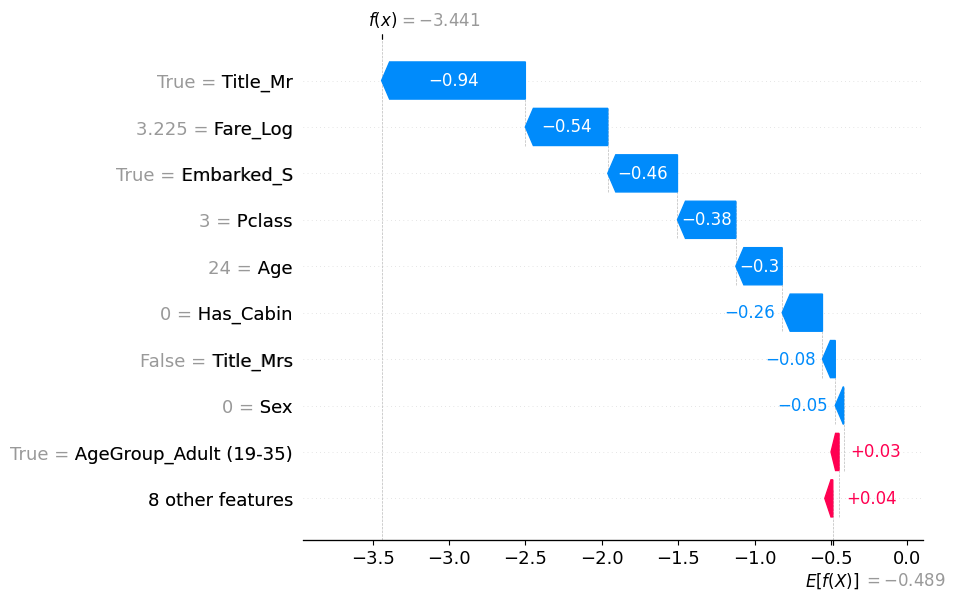

In [44]:
import shap

models = {
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    print("\n" + "="*50)
    print(f"SHAP - {name}")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)

    if len(shap_values.values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(shap_values, X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar")

    top_feature = X.columns[np.abs(shap_values.values).mean(axis=0).argmax()]
    shap.dependence_plot(top_feature, shap_values.values, X_test)

    shap.plots.waterfall(shap_values[0])

##**13. Model Comparison**

                 Model  Train_Acc  Test_Acc  Train_Prec  Test_Prec  Train_Rec  \
0        Random Forest     0.8539    0.8045      0.8506     0.7833     0.7509   
1  Logistic Regression     0.8301    0.8436      0.7815     0.7971     0.7729   
2              XGBoost     0.9410    0.8101      0.9565     0.7869     0.8864   

   Test_Rec  Train_F1  Test_F1  Overfit_Score  
0    0.6812    0.7977   0.7287         0.0495  
1    0.7971    0.7772   0.7971        -0.0135  
2    0.6957    0.9202   0.7385         0.1310  


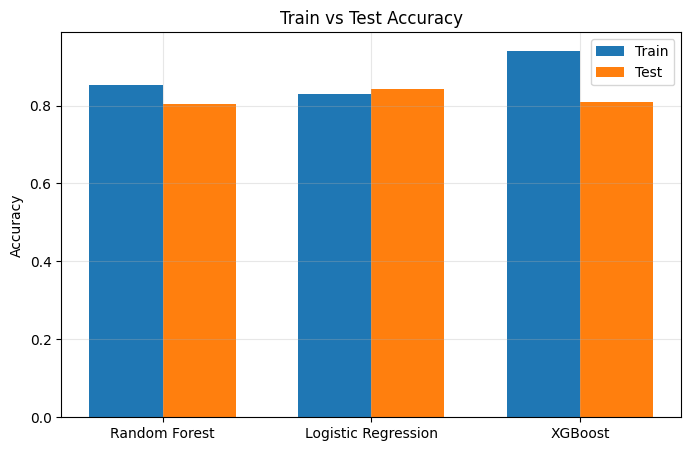

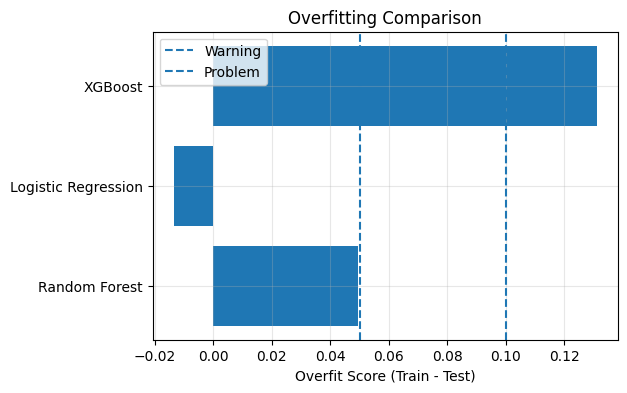

In [45]:
# =========================================================
# TRAIN vs TEST PERFORMANCE COMPARISON
# =========================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Helper: compute metrics
# -------------------------------
def compute_metrics(y_true, y_pred):
    return {
        "Acc": accuracy_score(y_true, y_pred),
        "Prec": precision_score(y_true, y_pred),
        "Rec": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

# -------------------------------
# Helper: train + evaluate
# -------------------------------
def train_eval(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)

    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)

    tr = compute_metrics(y_tr, tr_pred)
    te = compute_metrics(y_te, te_pred)

    row = {
        "Model": name,
        "Train_Acc": tr["Acc"], "Test_Acc": te["Acc"],
        "Train_Prec": tr["Prec"], "Test_Prec": te["Prec"],
        "Train_Rec": tr["Rec"], "Test_Rec": te["Rec"],
        "Train_F1": tr["F1"], "Test_F1": te["F1"],
        "Overfit_Score": tr["Acc"] - te["Acc"]
    }
    return row

# -------------------------------
# Run all models
# -------------------------------
results = []

results.append(train_eval(rf, X_train, X_test, y_train, y_test, "Random Forest"))
results.append(train_eval(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression"))
results.append(train_eval(xgb, X_train, X_test, y_train, y_test, "XGBoost"))

results_df = pd.DataFrame(results).round(4)
print(results_df)

# =========================================================
# VISUALIZATION 1: Train vs Test Accuracy
# =========================================================
x = np.arange(len(results_df))
w = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - w/2, results_df["Train_Acc"], w, label="Train")
plt.bar(x + w/2, results_df["Test_Acc"],  w, label="Test")

plt.xticks(x, results_df["Model"])
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================================================
# VISUALIZATION 2: Overfitting Score
# =========================================================
plt.figure(figsize=(6,4))
plt.barh(results_df["Model"], results_df["Overfit_Score"])

plt.axvline(0.05, linestyle='--', label='Warning')
plt.axvline(0.10, linestyle='--', label='Problem')

plt.xlabel("Overfit Score (Train - Test)")
plt.title("Overfitting Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ARTIFICIAL NEURAL NETWORK (ANN) IMPLEMENTATION

### WHAT IS A NEURAL NETWORK?

Inspired by the human brain:

- Network of interconnected neurons  
- Each neuron performs a simple calculation  
- Together, they learn complex patterns  

**Structure:**

Input Layer → Hidden Layer(s) → Output Layer  

Each connection has a weight (learned during training)

### NETWORK ARCHITECTURE

- **Input Layer:**  
  `n_features` neurons (one per feature)

- **Hidden Layer 1:**  
  16 neurons (ReLU activation)

- **Hidden Layer 2:**  
  8 neurons (ReLU activation)

- **Output Layer:**  
  1 neuron (Sigmoid activation → outputs probability)

### SUMMARY

- Total Layers: **4**
  - 1 Input Layer  
  - 2 Hidden Layers  
  - 1 Output Layer  

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Create model
ann = MLPClassifier(
    hidden_layer_sizes=(16, 8),  # Two hidden layers: 16 neurons, then 8
    activation='relu',            # ReLU activation for hidden layers
    solver='adam',                # Adam optimizer (adaptive learning rate)
    alpha=0.0001,                 # L2 regularization strength
    batch_size='auto',            # Batch size for training
    learning_rate='adaptive',     # Adaptive learning rate
    learning_rate_init=0.001,     # Initial learning rate
    max_iter=500,                 # Maximum epochs
    shuffle=True,                 # Shuffle data each epoch
    random_state=42,              # Reproducibility
    early_stopping=True,          # Stop if validation score doesn't improve
    validation_fraction=0.1,      # 10% of training data for validation
    n_iter_no_change=10,          # Stop if no improvement for 10 epochs
    verbose=False                 # Don't print progress (we'll show manually)
)

In [47]:
# Train
ann.fit(X_train_scaled, y_train)

print(f"✓ Training complete!")
print(f"  Total iterations: {ann.n_iter_}")
print(f"  Final training loss: {ann.loss_:.6f}")
print(f"  Training stopped: {'Early stopping' if ann.n_iter_ < 500 else 'Max iterations reached'}")


✓ Training complete!
  Total iterations: 40
  Final training loss: 0.438256
  Training stopped: Early stopping


In [48]:
# Predictions
print("\nMAKING PREDICTIONS:")

# Train predictions
ann_train_pred = ann.predict(X_train_scaled)
ann_train_proba = ann.predict_proba(X_train_scaled)[:, 1]

# Test predictions
ann_test_pred = ann.predict(X_test_scaled)
ann_test_proba = ann.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
ann_train_acc = accuracy_score(y_train, ann_train_pred)
ann_train_prec = precision_score(y_train, ann_train_pred)
ann_train_rec = recall_score(y_train, ann_train_pred)
ann_train_f1 = f1_score(y_train, ann_train_pred)

ann_test_acc = accuracy_score(y_test, ann_test_pred)
ann_test_prec = precision_score(y_test, ann_test_pred)
ann_test_rec = recall_score(y_test, ann_test_pred)
ann_test_f1 = f1_score(y_test, ann_test_pred)
ann_test_auc = roc_auc_score(y_test, ann_test_proba)

print("Performance Metrics:")
print(f"  Training   → Acc: {ann_train_acc:.4f} | Prec: {ann_train_prec:.4f} | Rec: {ann_train_rec:.4f} | F1: {ann_train_f1:.4f}")
print(f"  Test       → Acc: {ann_test_acc:.4f} | Prec: {ann_test_prec:.4f} | Rec: {ann_test_rec:.4f} | F1: {ann_test_f1:.4f}")
print(f"  ROC-AUC    → {ann_test_auc:.4f}")
print(f"  Overfit    → {ann_train_acc - ann_test_acc:+.4f}")


MAKING PREDICTIONS:
Performance Metrics:
  Training   → Acc: 0.8048 | Prec: 0.7680 | Rec: 0.7033 | F1: 0.7342
  Test       → Acc: 0.7598 | Prec: 0.6912 | Rec: 0.6812 | F1: 0.6861
  ROC-AUC    → 0.7996
  Overfit    → +0.0450


In [49]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cm_ann = confusion_matrix(y_test, ann_test_pred)

print("\n📋 CONFUSION MATRIX:")
print("-" * 80)
print("                Predicted")
print("             Died  Survived")
print(f"Actual  Died   {cm_ann[0,0]:3}     {cm_ann[0,1]:3}")
print(f"       Surv   {cm_ann[1,0]:3}     {cm_ann[1,1]:3}")



📋 CONFUSION MATRIX:
--------------------------------------------------------------------------------
                Predicted
             Died  Survived
Actual  Died    89      21
       Surv    22      47



📊 VISUALIZING ANN PERFORMANCE:


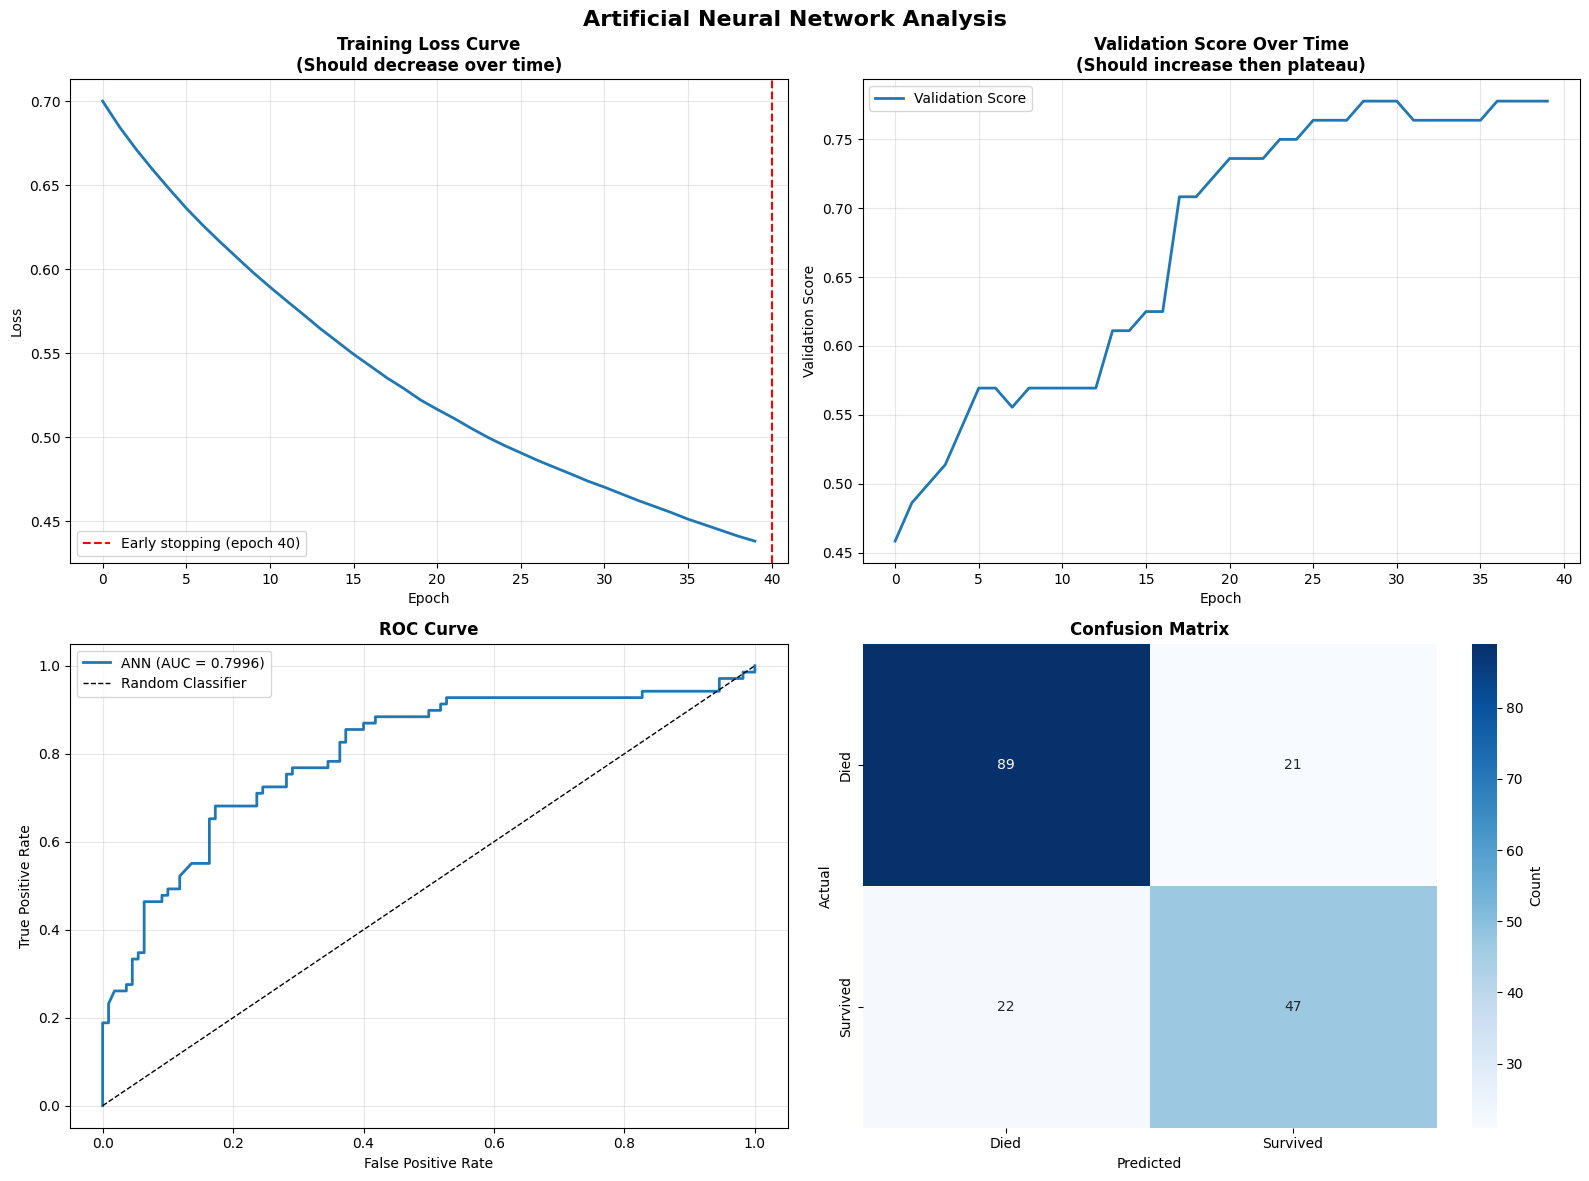

In [50]:
# Visualizations
print("\n📊 VISUALIZING ANN PERFORMANCE:")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Artificial Neural Network Analysis', fontsize=16, fontweight='bold')

# Plot 1: Training loss curve
if hasattr(ann, 'loss_curve_'):
    axes[0, 0].plot(ann.loss_curve_, linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss Curve\n(Should decrease over time)', fontweight='bold')
    axes[0, 0].grid(alpha=0.3)

    # Highlight early stopping point if applicable
    if ann.n_iter_ < 500:
        axes[0, 0].axvline(ann.n_iter_, color='red', linestyle='--',
                          label=f'Early stopping (epoch {ann.n_iter_})')
        axes[0, 0].legend()

  # Plot 2: Validation curve (if available)
if hasattr(ann, 'validation_scores_'):
    axes[0, 1].plot(ann.validation_scores_, linewidth=2, label='Validation Score')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Validation Score')
    axes[0, 1].set_title('Validation Score Over Time\n(Should increase then plateau)', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()
else:
    axes[0, 1].text(0.5, 0.5, 'Validation scores not recorded\n(Set validation_fraction > 0)',
                   ha='center', va='center', fontsize=12)
    axes[0, 1].set_title('Validation Scores', fontweight='bold')

# Plot 3: ROC Curve
from sklearn.metrics import roc_curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_test_proba)

axes[1, 0].plot(fpr_ann, tpr_ann, linewidth=2, label=f'ANN (AUC = {ann_test_auc:.4f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

#Confusion matrix heatmap
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()
